# 군 복무기 감염병 보장 네비게이터: 데이터 분석

- 2016~2025년 성별·연령별 10개 파일과 17개 시도×10년의 지역별 170개 파일을 long format으로 변환했다.
- KOSIS 인구 분모가 있는 2016~2023년을 주분석 기간으로 사용했다. 데이터 품질 점검은 **모두 통과**했다.
- NPS 상위 질환은 **말라리아 100.0점**, **쯔쯔가무시증 85.4점**, **신증후군출혈열 78.6점**이다.
- 말라리아는 20~24세 남성 AMR **7.92**, SMR **15.64**, 최대 월 비중 **25.4%(7월)**로 청년 남성·계절성이 동시에 강했다.
- 쯔쯔가무시증은 **11월 56.3%**, 신증후군출혈열은 **11월 23.7%**로 가을 집중도가 뚜렷했다.
- NPS는 8개 숏리스트 안의 **상대적 설명 우선순위**이며 발병확률·임상적 중증도·보험 보장 여부가 아니다.


## 0. Context & Methods

### 분석 목적

- 입영 예정자·군 복무자가 주의할 감염병의 설명 우선순위를 정한다.
- 질병 단위의 보험 보장 여부를 단정하지 않고, 지역·계절·연령 위험과 확인할 행동 경로를 구조화한다.
- 수치 계산은 공개 통계 파이프라인이 담당하고, 추후 RAG는 근거 문서 검색·요약만 담당한다.

### Key Assumptions

- 주분석 기간: **2016~2023년**. KOSIS 인구 분모가 이 기간까지만 제공된다.
- 2024~2025년은 long-format 결과에는 보존하지만 인구 기반 NPS에서는 제외한다.
- 지역 위험은 복무지역 맥락에 맞게 `국내` 감염 건수를 사용하며 `국외`는 별도 보존한다.
- 지역 파일은 `감염지역별` 통계이고 KOSIS는 주민등록 인구이므로 RQ는 엄밀한 거주지 기반 발생률이 아니라 **지역 집중도 근사치**로 해석한다.
- `-`, 공백, 비수치 값은 0이 아니라 결측으로 처리한다.
- 연령미상은 연령별 비교에서 제외한다. 전체 발생률은 원본의 `계/계` 행을 사용한다.
- 병무청 BMI 자료는 감염병 결과변수와 연결되지 않으므로 NPS에 넣지 않고 페르소나 문맥으로만 사용한다.
- NPS는 8개 숏리스트 내부의 상대 점수이며 발병확률·임상위험도·보험금 지급가능성이 아니다.


In [1]:
# 1. 환경과 분석 파라미터
from __future__ import annotations

import io
import json
import math
import re
import warnings
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, Markdown, display
from matplotlib import font_manager
from matplotlib.patches import FancyBboxPatch

warnings.filterwarnings("ignore", message="Workbook contains no default style")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

DATA_DIR = Path(r"C:\Users\user\SKKU\공모전\병무청공모전\data")
OUTPUT_DIR = Path(r"C:\Users\user\Documents\AI 활용 경진대회\outputs\감염병_분석_Actionability_문서근거")
PROCESSED_DIR = OUTPUT_DIR / "processed"
CHART_DIR = OUTPUT_DIR / "charts"
CARD_DIR = OUTPUT_DIR / "cards"
for folder in (OUTPUT_DIR, PROCESSED_DIR, CHART_DIR, CARD_DIR):
    folder.mkdir(parents=True, exist_ok=True)

MAIN_YEARS = list(range(2016, 2024))
ALL_YEARS = list(range(2016, 2026))
SHORTLIST = [
    "수두", "말라리아", "유행성이하선염", "백일해",
    "A형간염", "일본뇌염", "신증후군출혈열", "쯔쯔가무시증",
]

REGION_FULL_TO_SHORT = {
    "전국": "전국", "서울특별시": "서울", "부산광역시": "부산", "대구광역시": "대구",
    "인천광역시": "인천", "광주광역시": "광주", "대전광역시": "대전", "울산광역시": "울산",
    "세종특별자치시": "세종", "경기도": "경기", "강원도": "강원", "충청북도": "충북",
    "충청남도": "충남", "전라북도": "전북", "전라남도": "전남", "경상북도": "경북",
    "경상남도": "경남", "제주특별자치도": "제주",
}

# 5개 사용자 행동 축. 수집한 공식 문서의 근거표에서만 생성한다.
ACTIONABILITY_EVIDENCE_PATH = Path(r"C:\Users\user\Documents\AI 활용 경진대회\rag_prototype\data\structured\actionability_evidence.csv")
assert ACTIONABILITY_EVIDENCE_PATH.exists(), f"Actionability 근거표 누락: {ACTIONABILITY_EVIDENCE_PATH}"
actionability_evidence = pd.read_csv(ACTIONABILITY_EVIDENCE_PATH, encoding="utf-8-sig")
ACTION_DIMENSIONS = ["vaccination", "region_season", "exposure_prevention", "early_response", "navigation"]
assert set(actionability_evidence["disease"]) == set(SHORTLIST), "8개 질환 근거 누락"
assert set(actionability_evidence["dimension"]) == set(ACTION_DIMENSIONS), "5개 행동축 근거 누락"
assert actionability_evidence["evidence_quote"].fillna("").str.len().gt(0).all(), "근거 원문이 비어 있는 태그 존재"
_actionability_matrix = actionability_evidence.pivot(index="disease", columns="dimension", values="value").reindex(SHORTLIST)
assert _actionability_matrix.notna().all().all(), "질환×행동축 근거 행렬 결측"
ACTIONABILITY_TAGS = {
    disease: {dimension: int(_actionability_matrix.loc[disease, dimension]) for dimension in ACTION_DIMENSIONS}
    for disease in SHORTLIST
}
NPS_WEIGHTS = {"amr": 0.35, "rq": 0.25, "seasonality": 0.20, "actionability": 0.20}

required_files = [
    DATA_DIR / "성별연령별.zip", DATA_DIR / "지역별.zip",
    DATA_DIR / "시군구_성_연령_5세_별_주민등록연앙인구_20260629105323.xlsx",
    DATA_DIR / "군 감염병 정보.csv", DATA_DIR / "말라리아_기본통계_질병별.xlsx",
    DATA_DIR / "병무청_병역판정검사 신체질량지수(BMI) 및 청별 현황_20241231.csv",
]
missing_files = [str(path) for path in required_files if not path.exists()]
assert not missing_files, f"입력 파일 누락: {missing_files}"
print(f"입력 파일 {len(required_files)}개 확인 완료")


입력 파일 6개 확인 완료


## 1. Data 전처리

### 처리 규칙

| 항목 | 규칙 |
|---|---|
| `-`, 공백 | 결측(`NaN`)으로 보존 |
| 실제 `0` | 0건으로 보존 |
| 연령미상 | AMR·SMR에서 제외 |
| 국외 감염 | `cases_imported`로 보존, 지역 RQ·계절성에서는 제외 |
| 의료관련감염·희소 초고위험 질환 | long 원본에는 보존, NPS 분석에서는 숏리스트 밖으로 제외 |
| 2024~2025 | 최신 동향용으로 보존, KOSIS 분모가 없어 주 NPS에서 제외 |
| 신체검사 BMI | 페르소나 설명용, 감염병 점수에는 미사용 |


### 공통 정규화 및 입력 함수 정의
**핵심 함수**

- `normalize_numeric`: 쉼표 제거, `-`·공백을 결측으로 변환, 실제 `0`은 유지한다.
- `normalize_age_band`: `20 - 24세`와 `20~24세`를 같은 값으로 맞춘다.
- `normalize_disease`: `신증후군 출혈열`처럼 띄어쓰기 차이가 있는 질환명을 통일한다.
- `read_csv_detect`: UTF-8 → CP949 → EUC-KR 순으로 CSV 인코딩을 판별한다.
- `read_zip_excel`: ZIP을 풀지 않고 XLSX를 메모리에서 읽는다.

**원리**

조인 키는 눈으로 같아 보여도 공백이나 기호 하나가 다르면 매칭되지 않는다. 분석 전 정규화는 계산보다 먼저 수행되어야 한다.

In [2]:
# 2. 공통 정규화 및 입력 함수
def normalize_numeric(series: pd.Series) -> pd.Series:
    cleaned = (
        series.astype("string")
        .str.strip()
        .replace({"": pd.NA, "-": pd.NA, "nan": pd.NA, "None": pd.NA})
        .str.replace(",", "", regex=False)
    )
    return pd.to_numeric(cleaned, errors="coerce")


def normalize_age_band(value) -> str | None:
    if pd.isna(value):
        return None
    text = str(value).strip().replace(" ", "")
    if text == "계":
        return "all"
    text = text.replace("-", "~")
    return text


def normalize_disease(value) -> str | None:
    if pd.isna(value):
        return None
    text = re.sub(r"\s+", "", str(value).strip())
    aliases = {
        "A형간염": "A형간염", "에이형간염": "A형간염",
        "신증후군출혈열": "신증후군출혈열",
    }
    return aliases.get(text, text)


def read_csv_detect(path: Path) -> tuple[pd.DataFrame, str]:
    for encoding in ("utf-8-sig", "cp949", "euc-kr"):
        try:
            return pd.read_csv(path, encoding=encoding), encoding
        except UnicodeDecodeError:
            continue
    raise UnicodeError(f"인코딩 판별 실패: {path}")


def read_zip_excel(archive: zipfile.ZipFile, member: str) -> pd.DataFrame:
    with archive.open(member) as handle:
        payload = io.BytesIO(handle.read())
    return pd.read_excel(payload, header=None, engine="openpyxl")


### 전처리 a) `성별·연령별 파일`을 long format으로 변환
**원본 구조**

- 10개 파일, 각 56행×69열
- 66개 질환
- 행: 연령대×성별
- 열: 질환

**처리 원리**

1. 파일명에서 연도를 추출한다.
2. 원본 6번째 행에서 질환명, 5번째 행에서 감염병 등급을 읽는다.
3. 각 질환 열을 세로로 쌓아 `year-age-sex-disease` grain을 만든다.
4. 원본 파일명을 각 행에 남겨 추적 가능하게 한다.

**실행 결과**

- **31,680행** = 10년×48개 연령·성별 조합×66질환
- 10개 연도 모두 66질환, 결측 발생건수 0
- 예: 2016년 수두 전체 54,060건, 남성 28,735건, 여성 25,325건

**계획서 연결**: AMR·SMR을 계산할 수 있는 `year, age_band, sex, disease, cases` 구조를 완성한다.

In [3]:
def parse_sex_age_zip(path: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    frames = []
    file_audit = []
    with zipfile.ZipFile(path) as archive:
        members = sorted(name for name in archive.namelist() if name.lower().endswith(".xlsx"))
        for member in members:
            year = int(re.search(r"(20\d{2})", Path(member).name).group(1))
            raw = read_zip_excel(archive, member)
            diseases = [normalize_disease(v) for v in raw.iloc[5, 3:].tolist()]
            disease_classes = raw.iloc[4, 3:].astype("string").str.strip().tolist()
            body = raw.iloc[6:].copy()
            valid = body.iloc[:, 1].notna() & body.iloc[:, 2].notna()
            body = body.loc[valid]
            age_values = body.iloc[:, 1].map(normalize_age_band)
            sex_values = body.iloc[:, 2].astype("string").str.strip().map({"계": "all", "남": "male", "여": "female"})

            per_file = []
            for offset, (disease, disease_class) in enumerate(zip(diseases, disease_classes), start=3):
                if not disease:
                    continue
                per_file.append(pd.DataFrame({
                    "year": year,
                    "age_band": age_values.values,
                    "sex": sex_values.values,
                    "disease_class": disease_class,
                    "disease": disease,
                    "cases": normalize_numeric(body.iloc[:, offset]).values,
                    "source_file": Path(member).name,
                }))
            frame = pd.concat(per_file, ignore_index=True)
            frames.append(frame)
            file_audit.append({
                "source_file": Path(member).name, "year": year, "raw_rows": raw.shape[0], "raw_columns": raw.shape[1],
                "diseases": frame["disease"].nunique(), "missing_case_values": int(frame["cases"].isna().sum()),
            })
    return pd.concat(frames, ignore_index=True), pd.DataFrame(file_audit)


sex_age_long, sex_age_file_audit = parse_sex_age_zip(DATA_DIR / "성별연령별.zip")
sex_age_shortlist = sex_age_long[sex_age_long["disease"].isin(SHORTLIST)].copy()

display(sex_age_file_audit)
display(sex_age_shortlist.head(10))
print(f"성별·연령별 long: {len(sex_age_long):,}행 / 질병 {sex_age_long['disease'].nunique()}개")


,source_file,year,raw_rows,raw_columns,diseases,missing_case_values
0,2016_기본통계_성별_연령별.xlsx,2016,56,69,66,0
1,2017_기본통계_성별_연령별.xlsx,2017,56,69,66,0
2,2018_기본통계_성별_연령별.xlsx,2018,56,69,66,0
3,2019_기본통계_성별_연령별.xlsx,2019,56,69,66,0
4,2020_기본통계_성별_연령별.xlsx,2020,56,69,66,0
5,2021_기본통계_성별_연령별.xlsx,2021,56,69,66,0
6,2022_기본통계_성별_연령별.xlsx,2022,56,69,66,0
7,2023_기본통계_성별_연령별.xlsx,2023,56,69,66,0
8,2024_기본통계_성별_연령별.xlsx,2024,56,69,66,0
9,2025_기본통계_성별_연령별.xlsx,2025,56,69,66,0


,year,age_band,sex,disease_class,disease,cases,source_file
816,2016,all,all,제2급,수두,54060,2016_기본통계_성별_연령별.xlsx
817,2016,all,male,제2급,수두,28735,2016_기본통계_성별_연령별.xlsx
818,2016,all,female,제2급,수두,25325,2016_기본통계_성별_연령별.xlsx
819,2016,0~4세,all,제2급,수두,16289,2016_기본통계_성별_연령별.xlsx
820,2016,0~4세,male,제2급,수두,8624,2016_기본통계_성별_연령별.xlsx
821,2016,0~4세,female,제2급,수두,7665,2016_기본통계_성별_연령별.xlsx
822,2016,5~9세,all,제2급,수두,26918,2016_기본통계_성별_연령별.xlsx
823,2016,5~9세,male,제2급,수두,14427,2016_기본통계_성별_연령별.xlsx
824,2016,5~9세,female,제2급,수두,12491,2016_기본통계_성별_연령별.xlsx
825,2016,10~14세,all,제2급,수두,6948,2016_기본통계_성별_연령별.xlsx


성별·연령별 long: 31,680행 / 질병 66개


### 전처리 b) 지역별 파일을 long format으로 변환
**원본 구조**

- 170개 파일 = 10년×17개 시도
- 각 파일 22행×200열
- 질환마다 `계·국내·국외` 3열
- 1~12월과 연간계

**처리 원리**

1. 파일명에서 `year`, `region`을 뽑는다.
2. 질환명과 `계/국내/국외`의 2단 헤더를 읽는다.
3. 월별 행만 남기고 세로로 변환한다.
4. `계·국내·국외`를 다시 세 열로 피벗한다.
5. 연간계가 12개월 합과 같은지 별도 검증한다.

**실행 결과**

- **134,640행** = 10년×17지역×12개월×66질환
- 모든 연도에 17개 지역·66질환 존재
- `cases_total = cases_domestic + cases_imported` 불일치 0건
- 연간계와 월합 불일치 0건

**계획서 연결**: `year, region, month, disease, cases_total, cases_domestic, cases_imported` 구조를 완성한다.

In [4]:
def parse_regional_zip(path: Path) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    monthly_frames = []
    file_audit = []
    annual_checks = []
    with zipfile.ZipFile(path) as archive:
        members = sorted(name for name in archive.namelist() if name.lower().endswith(".xlsx"))
        for member in members:
            filename = Path(member).name
            match = re.search(r"(20\d{2})_(.+?)_기본통계_지역별", filename)
            year, region = int(match.group(1)), match.group(2)
            raw = read_zip_excel(archive, member)
            diseases = [normalize_disease(v) for v in raw.iloc[5, 2:].tolist()]
            origins = raw.iloc[6, 2:].astype("string").str.strip().tolist()
            body = raw.iloc[7:].copy()
            periods = body.iloc[:, 1].astype("string").str.strip()
            valid_period = periods.eq("계") | periods.str.match(r"^\d{2}월$", na=False)
            body, periods = body.loc[valid_period], periods.loc[valid_period]

            long_parts = []
            for offset, (disease, origin) in enumerate(zip(diseases, origins), start=2):
                if not disease or origin not in {"계", "국내", "국외"}:
                    continue
                long_parts.append(pd.DataFrame({
                    "period": periods.values,
                    "disease": disease,
                    "origin": origin,
                    "cases": normalize_numeric(body.iloc[:, offset]).values,
                }))
            stacked = pd.concat(long_parts, ignore_index=True)
            annual = stacked[stacked["period"].eq("계")].pivot_table(
                index="disease", columns="origin", values="cases", aggfunc="first", dropna=False
            )
            monthly = stacked[~stacked["period"].eq("계")].copy()
            monthly["month"] = monthly["period"].str.extract(r"(\d{2})")[0].astype(int)
            pivoted = monthly.pivot_table(
                index=["month", "disease"], columns="origin", values="cases", aggfunc="first", dropna=False
            ).reset_index()
            for column in ("계", "국내", "국외"):
                if column not in pivoted:
                    pivoted[column] = np.nan
            pivoted = pivoted.rename(columns={"계": "cases_total", "국내": "cases_domestic", "국외": "cases_imported"})
            pivoted.insert(0, "region", region)
            pivoted.insert(0, "year", year)
            pivoted["source_file"] = filename
            monthly_frames.append(pivoted[[
                "year", "region", "month", "disease", "cases_total", "cases_domestic", "cases_imported", "source_file"
            ]])

            monthly_sum = pivoted.groupby("disease")[["cases_total", "cases_domestic", "cases_imported"]].sum(min_count=1)
            for disease in set(monthly_sum.index).intersection(annual.index):
                annual_checks.append({
                    "year": year, "region": region, "disease": disease,
                    "annual_total_raw": annual.at[disease, "계"] if "계" in annual else np.nan,
                    "monthly_total_sum": monthly_sum.at[disease, "cases_total"],
                })
            file_audit.append({
                "source_file": filename, "year": year, "region": region,
                "raw_rows": raw.shape[0], "raw_columns": raw.shape[1], "diseases": pivoted["disease"].nunique(),
                "missing_case_values": int(pivoted[["cases_total", "cases_domestic", "cases_imported"]].isna().sum().sum()),
            })
    return pd.concat(monthly_frames, ignore_index=True), pd.DataFrame(file_audit), pd.DataFrame(annual_checks)


regional_long, regional_file_audit, regional_annual_checks = parse_regional_zip(DATA_DIR / "지역별.zip")
regional_shortlist = regional_long[regional_long["disease"].isin(SHORTLIST)].copy()

display(regional_file_audit.groupby("year").agg(files=("source_file", "count"), regions=("region", "nunique"), diseases=("diseases", "min")))
display(regional_shortlist.head(10))
print(f"지역별 long: {len(regional_long):,}행 / 질병 {regional_long['disease'].nunique()}개")


,files,regions,diseases
year,,,
2016,17,17,66
2017,17,17,66
2018,17,17,66
2019,17,17,66
2020,17,17,66
2021,17,17,66
2022,17,17,66
2023,17,17,66
2024,17,17,66


origin,year,region,month,disease,cases_total,cases_domestic,cases_imported,source_file
2,2016,강원,1,A형간염,6.0,6.0,0.0,2016_강원_기본통계_지역별.xlsx
19,2016,강원,1,말라리아,0.0,0.0,0.0,2016_강원_기본통계_지역별.xlsx
25,2016,강원,1,백일해,0.0,0.0,0.0,2016_강원_기본통계_지역별.xlsx
31,2016,강원,1,수두,213.0,213.0,0.0,2016_강원_기본통계_지역별.xlsx
34,2016,강원,1,신증후군출혈열,1.0,1.0,0.0,2016_강원_기본통계_지역별.xlsx
39,2016,강원,1,유행성이하선염,23.0,23.0,0.0,2016_강원_기본통계_지역별.xlsx
40,2016,강원,1,일본뇌염,0.0,0.0,0.0,2016_강원_기본통계_지역별.xlsx
48,2016,강원,1,쯔쯔가무시증,3.0,3.0,0.0,2016_강원_기본통계_지역별.xlsx
68,2016,강원,2,A형간염,6.0,6.0,0.0,2016_강원_기본통계_지역별.xlsx
85,2016,강원,2,말라리아,1.0,0.0,1.0,2016_강원_기본통계_지역별.xlsx


지역별 long: 134,640행 / 질병 66개


### 전처리 c) KOSIS 인구와 보조자료 로드

**KOSIS 처리**

KOSIS 표는 연도와 지역이 병합셀처럼 비어 있는 행이 있으므로 `ffill()`로 위 값을 아래로 채운다. 이후 연령열을 세로로 녹여 다음 grain을 만든다.

`year | region | sex | age_band | population`

**실행 결과**

- KOSIS 범위: 2016~2023년
- 전국 2016년 연앙인구: 51,112,971.5명
- 군 감염병 CSV와 BMI CSV는 모두 CP949로 판별

**보조자료의 역할**

- 군 감염병 자료는 `cases_military`라는 참고 열로만 결합한다.
- BMI는 감염병 결과와 연결된 개인 패널이 아니므로 NPS 수식에 넣지 않는다.
- 말라리아 XLSX는 별도 검증용이다.

In [5]:
population_raw = pd.read_excel(
    DATA_DIR / "시군구_성_연령_5세_별_주민등록연앙인구_20260629105323.xlsx",
    sheet_name="데이터", engine="openpyxl"
)
population_raw["시점"] = population_raw["시점"].ffill().astype(int)
population_raw["행정구역(시군구)별"] = population_raw["행정구역(시군구)별"].ffill()
population_raw["sex"] = population_raw["성별"].map({"계": "all", "남자": "male", "여자": "female"})
population_raw["region"] = population_raw["행정구역(시군구)별"].map(REGION_FULL_TO_SHORT)

population_long = population_raw.melt(
    id_vars=["시점", "region", "sex"],
    value_vars=["계", "0 - 4세", "5 - 9세", "10 - 14세", "15 - 19세", "20 - 24세", "25 - 29세",
                "30 - 34세", "35 - 39세", "40 - 44세", "45 - 49세", "50 - 54세", "55 - 59세",
                "60 - 64세", "65 - 69세", "70 - 74세", "75 - 79세", "80세 이상"],
    var_name="age_band", value_name="population"
).rename(columns={"시점": "year"})
population_long["age_band"] = population_long["age_band"].map(normalize_age_band)
population_long["population"] = pd.to_numeric(population_long["population"], errors="coerce")

military_infections, military_encoding = read_csv_detect(DATA_DIR / "군 감염병 정보.csv")
military_infections["disease"] = military_infections["질병명"].map(normalize_disease)
military_infections["cases_military"] = pd.to_numeric(military_infections["현황"], errors="coerce")
military_context = (
    military_infections[military_infections["disease"].isin(SHORTLIST)]
    .groupby("disease", as_index=False)["cases_military"].sum()
)

bmi_context, bmi_encoding = read_csv_detect(DATA_DIR / "병무청_병역판정검사 신체질량지수(BMI) 및 청별 현황_20241231.csv")

malaria_raw = pd.read_excel(DATA_DIR / "말라리아_기본통계_질병별.xlsx", header=None, engine="openpyxl")
malaria_validation = malaria_raw.iloc[5:15, 1:15].copy()
malaria_validation.columns = ["year", "annual_total"] + [f"month_{m:02d}" for m in range(1, 13)]
malaria_validation["year"] = pd.to_numeric(malaria_validation["year"], errors="coerce").astype("Int64")
for column in malaria_validation.columns[1:]:
    malaria_validation[column] = pd.to_numeric(malaria_validation[column], errors="coerce")

display(population_long.head())
print(f"KOSIS 연도: {population_long.year.min()}~{population_long.year.max()}, CSV 인코딩: 군 감염병={military_encoding}, BMI={bmi_encoding}")


,year,region,sex,age_band,population
0,2016,전국,all,all,51112971.5
1,2016,전국,male,all,25527814.5
2,2016,전국,female,all,25585157.0
3,2016,서울,all,all,9811038.5
4,2016,서울,male,all,4818222.5


KOSIS 연도: 2016~2023, CSV 인코딩: 군 감염병=cp949, BMI=cp949

## 2. Results


### 2-a) 데이터 품질 및 분석 가능성

**검사 원리**

- 키 중복: 같은 연도·연령·성별·질환이 두 번 세어지는지 확인
- 음수: 발생건수에 불가능한 음수가 있는지 확인
- 가법성: `계=국내+국외`, `연간계=12개월합` 확인
- 숏리스트 커버리지: 8개 질환이 두 핵심 원천에 모두 있는지 확인

> 일본뇌염은 군 감염병 CSV에 없지만 질병관리청 두 자료에는 존재한다. 군 CSV는 보조자료이므로 NPS 계산에는 문제가 없다.

In [6]:
sex_age_key = ["year", "age_band", "sex", "disease"]
regional_key = ["year", "region", "month", "disease"]

shortlist_coverage = pd.DataFrame({
    "disease": SHORTLIST,
    "sex_age_present": [d in set(sex_age_long["disease"]) for d in SHORTLIST],
    "regional_present": [d in set(regional_long["disease"]) for d in SHORTLIST],
    "military_context_present": [d in set(military_infections["disease"]) for d in SHORTLIST],
})

regional_additivity = regional_shortlist.dropna(subset=["cases_total", "cases_domestic", "cases_imported"]).copy()
regional_additivity["gap"] = regional_additivity["cases_total"] - regional_additivity["cases_domestic"] - regional_additivity["cases_imported"]
annual_check = regional_annual_checks.dropna(subset=["annual_total_raw", "monthly_total_sum"]).copy()
annual_check["gap"] = annual_check["annual_total_raw"] - annual_check["monthly_total_sum"]

quality_summary = pd.DataFrame([
    {"check": "성별·연령 ZIP 파일 수", "observed": sex_age_file_audit.shape[0], "expected": 10, "status": "PASS" if sex_age_file_audit.shape[0] == 10 else "FAIL"},
    {"check": "지역 ZIP 파일 수", "observed": regional_file_audit.shape[0], "expected": 170, "status": "PASS" if regional_file_audit.shape[0] == 170 else "FAIL"},
    {"check": "성별·연령 키 중복", "observed": int(sex_age_long.duplicated(sex_age_key).sum()), "expected": 0, "status": "PASS" if not sex_age_long.duplicated(sex_age_key).any() else "FAIL"},
    {"check": "지역 키 중복", "observed": int(regional_long.duplicated(regional_key).sum()), "expected": 0, "status": "PASS" if not regional_long.duplicated(regional_key).any() else "FAIL"},
    {"check": "음수 발생건수", "observed": int((sex_age_long["cases"].dropna() < 0).sum() + (regional_long[["cases_total", "cases_domestic", "cases_imported"]].dropna() < 0).sum().sum()), "expected": 0, "status": "PASS" if int((sex_age_long["cases"].dropna() < 0).sum() + (regional_long[["cases_total", "cases_domestic", "cases_imported"]].dropna() < 0).sum().sum()) == 0 else "FAIL"},
    {"check": "계=국내+국외 불일치(숏리스트 월)", "observed": int((regional_additivity["gap"].abs() > 1e-9).sum()), "expected": 0, "status": "PASS" if (regional_additivity["gap"].abs() <= 1e-9).all() else "WARN"},
    {"check": "연간계=월합 불일치(전체 질병)", "observed": int((annual_check["gap"].abs() > 1e-9).sum()), "expected": 0, "status": "PASS" if (annual_check["gap"].abs() <= 1e-9).all() else "WARN"},
    {"check": "숏리스트 양쪽 데이터 존재", "observed": int((shortlist_coverage["sex_age_present"] & shortlist_coverage["regional_present"]).sum()), "expected": len(SHORTLIST), "status": "PASS" if (shortlist_coverage["sex_age_present"] & shortlist_coverage["regional_present"]).all() else "FAIL"},
])

display(quality_summary)
display(shortlist_coverage)


,check,observed,expected,status
0,성별·연령 ZIP 파일 수,10,10,PASS
1,지역 ZIP 파일 수,170,170,PASS
2,성별·연령 키 중복,0,0,PASS
3,지역 키 중복,0,0,PASS
4,음수 발생건수,0,0,PASS
5,계=국내+국외 불일치(숏리스트 월),0,0,PASS
6,연간계=월합 불일치(전체 질병),0,0,PASS
7,숏리스트 양쪽 데이터 존재,8,8,PASS


,disease,sex_age_present,regional_present,military_context_present
0,수두,True,True,True
1,말라리아,True,True,True
2,유행성이하선염,True,True,True
3,백일해,True,True,True
4,A형간염,True,True,True
5,일본뇌염,True,True,False
6,신증후군출혈열,True,True,True
7,쯔쯔가무시증,True,True,True


### 2-b) 인구 분모 결합과 발생률 계산

**조인 키**

- 성별·연령: `year + age_band + sex`
- 지역: `year + region`

**실행 결과**

- 성별·연령 분석행 384행, 인구 누락 0
- 지역 연간 분석행 1,088행, 인구 누락 0

384행은 8년×8질환×(`전체 계` 1개 + `20~24세 남녀` 2개)다. AMR·SMR에 필요한 집단만 분모 조인한다. 고령 세부구간은 KOSIS와 감염병 파일의 구간 체계가 달라 억지로 조인하지 않는다.

In [7]:
main_sex_age = sex_age_shortlist[
    sex_age_shortlist["year"].isin(MAIN_YEARS) & sex_age_shortlist["age_band"].isin(["all", "20~24세"])
].copy()
national_population = population_long[population_long["region"].eq("전국")][["year", "age_band", "sex", "population"]]
main_sex_age = main_sex_age.merge(national_population, on=["year", "age_band", "sex"], how="left", validate="many_to_one")
main_sex_age["rate_per_100k"] = main_sex_age["cases"] / main_sex_age["population"] * 100_000

region_population = population_long[
    population_long["region"].ne("전국") & population_long["age_band"].eq("all") & population_long["sex"].eq("all")
][["year", "region", "population"]]
region_annual = (
    regional_shortlist[regional_shortlist["year"].isin(MAIN_YEARS)]
    .groupby(["year", "region", "disease"], as_index=False)
    .agg(cases_total=("cases_total", "sum"), cases_domestic=("cases_domestic", "sum"), cases_imported=("cases_imported", "sum"))
    .merge(region_population, on=["year", "region"], how="left", validate="many_to_one")
)
region_annual["rate_per_100k"] = region_annual["cases_domestic"] / region_annual["population"] * 100_000

join_quality = pd.DataFrame([
    {"join": "성별·연령→전국 인구", "rows": len(main_sex_age), "population_missing": int(main_sex_age["population"].isna().sum())},
    {"join": "지역→시도 인구", "rows": len(region_annual), "population_missing": int(region_annual["population"].isna().sum())},
])
display(join_quality)
assert join_quality["population_missing"].sum() == 0, "인구 조인 누락 발생"


,join,rows,population_missing
0,성별·연령→전국 인구,384,0
1,지역→시도 인구,1088,0


### 2-c) 4가지 지표 계산
#### AMR

`AMR_d = 20~24세 남성 발생률 ÷ 전체 인구 발생률`

- 1보다 크면 청년 남성에서 전체 인구보다 상대적으로 두드러진다.
- ex. 말라리아: `8.052 ÷ 1.017 = 7.920`

#### SMR

`SMR_d = 20~24세 남성 발생률 ÷ 20~24세 여성 발생률`

- 말라리아: `8.052 ÷ 0.515 = 15.644`
- 신증후군출혈열: 16.037

#### RQ

`RQ_(r,d) = 지역 발생률 ÷ 전국 발생률`

- 1이면 전국 평균 수준
- 2이면 전국 평균의 약 2배 집중
- 경기 말라리아 RQ는 **2.348**

NPS에 지역 하나의 극단값이 그대로 들어가지 않도록 질병별 상위 3개 지역 RQ 평균을 사용한다. 이는 계획서에 없던 **안정화 조치**다. 예를 들어 말라리아는 인천 2.7, 경기 2.3, 강원 1.0의 평균인 2.044를 사용한다.

#### Seasonality

`Seasonality_d = 가장 많은 달의 국내 발생건수 ÷ 12개월 국내 발생건수`

기본 NPS에서는 전국 17개 시도를 합한 질병별 계절성을 사용한다. 지역 개인화용 `Seasonality_(r,d)`는 코드 셀 10에서 따로 계산한다.

#### Actionability

“공식 문서에서 사용자가 실행할 수 있는 안내축의 존재 비율”
(임상 중증도나 통계적 추정치가 아님)

각 행은 문서명, 근거 위치, 원문 발췌, 출처등급, 현행성 상태를 포함한다. 말라리아·쯔쯔가무시증의 예방접종 축은 0, 일본뇌염·신증후군출혈열은 5개 축이 모두 1이다. 이 점수는 임상적 중증도가 아니라 **공식 문서에서 사용자가 실행할 수 있는 안내축의 존재 비율**이다.


In [8]:
# 8. AMR·SMR·RQ·Seasonality 계산
def aggregate_rate(frame: pd.DataFrame, label: str) -> pd.DataFrame:
    result = frame.groupby("disease", as_index=False).agg(cases=("cases", "sum"), population=("population", "sum"))
    result[label] = result["cases"] / result["population"] * 100_000
    return result[["disease", label]]


male_20_24 = aggregate_rate(main_sex_age.query("age_band == '20~24세' and sex == 'male'"), "rate_male_20_24")
female_20_24 = aggregate_rate(main_sex_age.query("age_band == '20~24세' and sex == 'female'"), "rate_female_20_24")
all_population_rate = aggregate_rate(main_sex_age.query("age_band == 'all' and sex == 'all'"), "rate_all")

demographic_metrics = male_20_24.merge(female_20_24, on="disease").merge(all_population_rate, on="disease")
demographic_metrics["amr"] = demographic_metrics["rate_male_20_24"] / demographic_metrics["rate_all"].replace(0, np.nan)
demographic_metrics["smr"] = demographic_metrics["rate_male_20_24"] / demographic_metrics["rate_female_20_24"].replace(0, np.nan)

period_region = region_annual.groupby(["region", "disease"], as_index=False).agg(
    cases_domestic=("cases_domestic", "sum"), population=("population", "sum")
)
period_region["rate_per_100k"] = period_region["cases_domestic"] / period_region["population"] * 100_000
national_person_years = population_long.query("region == '전국' and age_band == 'all' and sex == 'all' and year in @MAIN_YEARS")["population"].sum()
national_disease = period_region.groupby("disease", as_index=False)["cases_domestic"].sum()
national_disease["national_rate_per_100k"] = national_disease["cases_domestic"] / national_person_years * 100_000
period_region = period_region.merge(national_disease[["disease", "national_rate_per_100k"]], on="disease")
period_region["rq"] = period_region["rate_per_100k"] / period_region["national_rate_per_100k"].replace(0, np.nan)

# 단일 소지역·희소건수 극단값을 줄이기 위해 질병별 상위 3개 지역 RQ 평균을 NPS 구성값으로 사용
rq_metric = (
    period_region.sort_values(["disease", "rq"], ascending=[True, False])
    .groupby("disease").head(3)
    .groupby("disease", as_index=False)["rq"].mean()
    .rename(columns={"rq": "rq_top3_mean"})
)

monthly_pattern = (
    regional_shortlist.query("year in @MAIN_YEARS")
    .groupby(["disease", "month"], as_index=False)["cases_domestic"].sum()
)
monthly_pattern["annual_cases"] = monthly_pattern.groupby("disease")["cases_domestic"].transform("sum")
monthly_pattern["monthly_share"] = monthly_pattern["cases_domestic"] / monthly_pattern["annual_cases"].replace(0, np.nan)
seasonality_metric = (
    monthly_pattern.loc[monthly_pattern.groupby("disease")["monthly_share"].idxmax(), ["disease", "month", "monthly_share"]]
    .rename(columns={"month": "peak_month", "monthly_share": "seasonality"})
)

actionability = pd.DataFrame.from_dict(ACTIONABILITY_TAGS, orient="index").reset_index(names="disease")
tag_columns = [c for c in actionability.columns if c != "disease"]
actionability["actionability"] = actionability[tag_columns].mean(axis=1)

metrics = (
    demographic_metrics.merge(rq_metric, on="disease", how="left")
    .merge(seasonality_metric, on="disease", how="left")
    .merge(actionability, on="disease", how="left")
    .merge(military_context, on="disease", how="left")
)
metrics["cases_military"] = metrics["cases_military"].fillna(0)
display(metrics.round(3))


,disease,rate_male_20_24,rate_female_20_24,rate_all,amr,smr,rq_top3_mean,peak_month,seasonality,vaccination,region_season,exposure_prevention,early_response,navigation,actionability,cases_military
0,A형간염,4.912,8.268,10.466,0.469,0.594,2.309,5,0.118,1,0,1,1,1,0.8,102.0
1,말라리아,8.052,0.515,1.017,7.92,15.644,2.044,7,0.254,0,1,1,1,1,0.8,781.0
2,백일해,0.015,0.097,0.583,0.025,0.151,2.643,11,0.134,1,0,1,1,1,0.8,40.0
3,수두,21.322,24.152,100.314,0.213,0.883,1.664,12,0.132,1,0,1,1,1,0.8,1262.0
4,신증후군출혈열,1.29,0.08,0.798,1.617,16.037,3.91,11,0.237,1,1,1,1,1,1.0,105.0
5,유행성이하선염,8.147,9.08,25.096,0.325,0.897,1.486,5,0.122,1,0,1,1,1,0.8,188.0
6,일본뇌염,0.007,0.008,0.036,0.205,0.906,1.851,10,0.417,1,1,1,1,1,1.0,0.0
7,쯔쯔가무시증,2.478,1.391,13.314,0.186,1.781,3.6,11,0.563,0,1,1,1,1,0.8,100.0


### 2-d) NPS 계산
>> 계획서 식을 그대로 사용

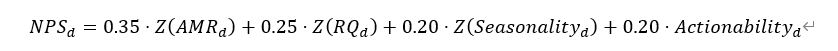

- **Z-score를 쓰는 이유**

    - AMR, RQ, Seasonality는 단위와 범위가 다르다. 

    - Z-score는 각 지표를 평균 0, 표준편차 1로 바꿔 한 식에서 결합할 수 있게 한다.

- **0~100 변환**

    - raw 점수는 음수가 될 수 있으므로 8개 숏리스트 내부에서 min-max 변환한다.

    - 따라서 100은 발병확률 100%가 아니며, 0도 위험이 없다는 뜻이 아니다. **현재 8개 중 상대적 최고와 최저**라는 뜻이다.
- 따라서 결과치의 100은 발병확률 100%가 아니며, 0도 위험이 없다는 뜻이 아니다. **현재 8개 중 상대적 최고와 최저**라는 뜻

In [9]:
# 9. NPS 계산: 상대 우선설명점수(0~100)
def zscore(series: pd.Series) -> pd.Series:
    std = series.std(ddof=0)
    return (series - series.mean()) / std if std and not np.isclose(std, 0) else pd.Series(0.0, index=series.index)


metrics["z_amr"] = zscore(metrics["amr"])
metrics["z_rq"] = zscore(metrics["rq_top3_mean"])
metrics["z_seasonality"] = zscore(metrics["seasonality"])
metrics["nps_raw"] = (
    NPS_WEIGHTS["amr"] * metrics["z_amr"]
    + NPS_WEIGHTS["rq"] * metrics["z_rq"]
    + NPS_WEIGHTS["seasonality"] * metrics["z_seasonality"]
    + NPS_WEIGHTS["actionability"] * metrics["actionability"]
)
nps_min, nps_max = metrics["nps_raw"].min(), metrics["nps_raw"].max()
metrics["nps"] = 100 * (metrics["nps_raw"] - nps_min) / (nps_max - nps_min) if nps_max > nps_min else 50.0
metrics["nps"] = metrics["nps"].clip(0, 100)
metrics["rank"] = metrics["nps"].rank(method="min", ascending=False).astype(int)

top_regions = (
    period_region.sort_values(["disease", "rq"], ascending=[True, False])
    .groupby("disease").head(3)
    .groupby("disease")
    .apply(lambda x: ", ".join(f"{r.region}({r.rq:.1f})" for _, r in x.iterrows()), include_groups=False)
    .rename("top_regions")
    .reset_index()
)
top_months = (
    monthly_pattern.sort_values(["disease", "monthly_share"], ascending=[True, False])
    .groupby("disease").head(3)
    .groupby("disease")
    .apply(lambda x: ", ".join(f"{int(r.month)}월({r.monthly_share:.0%})" for _, r in x.iterrows()), include_groups=False)
    .rename("top_months")
    .reset_index()
)
metrics = metrics.merge(top_regions, on="disease", how="left").merge(top_months, on="disease", how="left")
metrics = metrics.sort_values("nps", ascending=False).reset_index(drop=True)

nps_table = metrics[[
    "rank", "disease", "nps", "amr", "smr", "rate_male_20_24", "rate_all", "rq_top3_mean",
    "seasonality", "peak_month", "actionability", "cases_military", "top_regions", "top_months"
]].copy()
display(nps_table.round(3))


,rank,disease,nps,amr,smr,rate_male_20_24,rate_all,rq_top3_mean,seasonality,peak_month,actionability,cases_military,top_regions,top_months
0,1,말라리아,100.0,7.92,15.644,8.052,1.017,2.044,0.254,7,0.8,781.0,"인천(2.7), 경기(2.3), 강원(1.0)","7월(25%), 6월(22%), 8월(18%)"
1,2,쯔쯔가무시증,85.376,0.186,1.781,2.478,13.314,3.6,0.563,11,0.8,100.0,"전남(4.6), 경남(3.2), 전북(3.0)","11월(56%), 10월(23%), 12월(7%)"
2,3,신증후군출혈열,78.561,1.617,16.037,1.29,0.798,3.91,0.237,11,1.0,105.0,"전남(4.7), 전북(3.6), 충남(3.5)","11월(24%), 10월(15%), 12월(11%)"
3,4,일본뇌염,37.152,0.205,0.906,0.007,0.036,1.851,0.417,10,1.0,0.0,"강원(2.1), 광주(2.0), 서울(1.5)","10월(42%), 9월(41%), 8월(9%)"
4,5,백일해,23.01,0.025,0.151,0.015,0.583,2.643,0.134,11,0.8,40.0,"경남(3.7), 세종(2.3), 광주(1.9)","11월(13%), 12월(13%), 8월(11%)"
5,6,A형간염,18.759,0.469,0.594,4.912,10.466,2.309,0.118,5,0.8,102.0,"대전(3.0), 세종(2.1), 충남(1.8)","5월(12%), 8월(11%), 6월(11%)"
6,7,수두,3.682,0.213,0.883,21.322,100.314,1.664,0.132,12,0.8,1262.0,"제주(1.9), 세종(1.7), 경남(1.4)","12월(13%), 5월(11%), 11월(11%)"
7,8,유행성이하선염,0.0,0.325,0.897,8.147,25.096,1.486,0.122,5,0.8,188.0,"광주(1.5), 경남(1.5), 울산(1.4)","5월(12%), 6월(11%), 4월(10%)"


#### 결과 해석

- 말라리아는 AMR·SMR이 압도적으로 높아 1위다.
- 쯔쯔가무시증은 청년남성 AMR은 낮지만 지역집중도와 11월 집중도가 강해 2위다.
- 신증후군출혈열은 SMR·지역집중도·행동가능성이 모두 높아 3위다.
- 수두는 절대 발생률이 가장 높지만 AMR이 0.213이라 군 청년남성 특화점수에서는 낮다. 이는 현재 NPS가 **절대 질병부담이 아니라 군 타깃 설명 우선순위**를 측정하기 때문이다.
- 일본뇌염은 건수가 매우 적어도 특정 월 집중도와 행동가능성이 높아 4위다. 희소질환의 비율이 과대해질 수 있으므로 발표 때 건수도 함께 보여야 한다.

### 2-e) 지역별 계절성과 PNPS

#### 지역별 계절성

각 `region-disease`에서 다음을 계산한다.

`MonthFactor_(r,d,m) = 해당 지역·질병·월 국내건수 ÷ 해당 지역·질병 12개월 국내건수`

- 17지역×8질환 = 136조합을 모두 유지한다.
- 8년간 0건인 4조합은 계절성이 0이 아니라 `정의 불가`다.
- 0건이 아닌데 계절성이 미정의인 조합은 0건이다.

#### PNPS

`PNPS_(u,d) = NPS_d × RQ_(region,d) × MonthShare_(region,d,month)`

사용자에게는 같은 지역·월 안에서 0~100으로 다시 나누어 순위를 보여준다. 이 점수도 확률이 아니다.

| 선택지역 | 선택월 | 개인화순위 | 질환      | PNPS상대점수 | RegionFactor | MonthFactor |
| ---- | --- | ----- | ------- | -------- | ------------ | ----------- |
| 강원   | 7월  | 1     | 말라리아    | 100.000  | 1.047        | 0.302       |
| 강원   | 7월  | 2     | 신증후군출혈열 | 81.495   | 1.730        | 0.189       |
| 강원   | 7월  | 3     | A형간염    | 4.600    | 0.660        | 0.117       |
| 충북   | 10월 | 1     | 쯔쯔가무시증  | 100.000  | 0.706        | 0.301       |
| 충북   | 10월 | 2     | 신증후군출혈열 | 81.310   | 1.403        | 0.134       |
| 충북   | 10월 | 3     | 일본뇌염    | 45.943   | 1.346        | 0.167       |
| 전남   | 11월 | 1     | 쯔쯔가무시증  | 100.000  | 4.606        | 0.509       |
| 전남   | 11월 | 2     | 신증후군출혈열 | 45.479   | 4.653        | 0.249       |
| 전남   | 11월 | 3     | 백일해     | 2.405    | 1.465        | 0.143       |

강원 7월은 말라리아가 1위, 신증후군출혈열이 2위다. 충북 10월과 전남 11월은 쯔쯔가무시증이 1위로 바뀐다. 즉 PNPS는 “지역과 시기에 따라 카드 순서가 달라지는” 대시보드 기능을 실제로 구현하는 포인트가 바로 여기다.

In [10]:
# 10. 지역별 계절성 및 사용자 지역·월 PNPS 계산
# 계획서의 Seasonality_(r,d)를 구현: 각 지역·질병에서 특정 월이 8년 합계의 몇 %인지 계산
region_month_features = (
    regional_shortlist.query("year in @MAIN_YEARS")
    .groupby(["region", "disease", "month"], as_index=False)["cases_domestic"].sum()
)
region_month_features["region_disease_cases"] = region_month_features.groupby(
    ["region", "disease"]
)["cases_domestic"].transform("sum")
region_month_features["monthly_share_region"] = (
    region_month_features["cases_domestic"]
    / region_month_features["region_disease_cases"].replace(0, np.nan)
)
region_month_features = region_month_features.merge(
    period_region[["region", "disease", "rq", "rate_per_100k"]],
    on=["region", "disease"], how="left", validate="many_to_one"
)

region_seasonality_observed = (
    region_month_features.dropna(subset=["monthly_share_region"])
    .loc[lambda d: d.groupby(["region", "disease"])["monthly_share_region"].idxmax()]
    [["region", "disease", "month", "monthly_share_region", "rq", "rate_per_100k", "region_disease_cases"]]
    .rename(columns={"month": "peak_month_region", "monthly_share_region": "seasonality_region"})
    .sort_values(["region", "disease"])
    .reset_index(drop=True)
)
region_disease_grid = pd.MultiIndex.from_product(
    [sorted(region_month_features["region"].unique()), SHORTLIST], names=["region", "disease"]
).to_frame(index=False)
region_disease_totals = region_month_features.groupby(["region", "disease"], as_index=False)["cases_domestic"].sum().rename(
    columns={"cases_domestic": "region_disease_cases_all"}
)
region_seasonality = region_disease_grid.merge(
    region_disease_totals, on=["region", "disease"], how="left", validate="one_to_one"
).merge(
    region_seasonality_observed.drop(columns=["region_disease_cases"]),
    on=["region", "disease"], how="left", validate="one_to_one"
)
region_seasonality["seasonality_defined"] = region_seasonality["seasonality_region"].notna()


def calculate_pnps(region: str, month: int) -> pd.DataFrame:
    # 계획서 식 PNPS = NPS × RegionFactor(RQ) × MonthFactor(지역 월비중)를 직접 구현한다.
    if region not in set(region_month_features["region"]):
        raise ValueError(f"지원하지 않는 지역: {region}")
    if month not in range(1, 13):
        raise ValueError("month는 1~12여야 합니다.")
    local = region_month_features.query("region == @region and month == @month")[
        ["disease", "rq", "monthly_share_region", "cases_domestic"]
    ]
    result = metrics[["disease", "nps", "amr", "smr", "actionability"]].merge(local, on="disease", how="left")
    result["region_factor"] = result["rq"].fillna(0)
    result["month_factor"] = result["monthly_share_region"].fillna(0)
    result["pnps_raw"] = result["nps"] * result["region_factor"] * result["month_factor"]
    max_score = result["pnps_raw"].max()
    result["pnps_0_100"] = 100 * result["pnps_raw"] / max_score if max_score > 0 else 0.0
    result["personalized_rank"] = result["pnps_raw"].rank(method="min", ascending=False).astype(int)
    result["selected_region"] = region
    result["selected_month"] = month
    return result.sort_values(["personalized_rank", "disease"]).reset_index(drop=True)


pnps_examples = pd.concat([
    calculate_pnps("강원", 7).head(3),
    calculate_pnps("충북", 10).head(3),
    calculate_pnps("전남", 11).head(3),
], ignore_index=True)
display(region_seasonality.head(12).round(3))
display(pnps_examples[["selected_region", "selected_month", "personalized_rank", "disease", "pnps_0_100", "region_factor", "month_factor"]].round(3))


,region,disease,region_disease_cases_all,peak_month_region,seasonality_region,rq,rate_per_100k,seasonality_defined
0,강원,수두,10884.0,12.0,0.119,0.886,88.835,True
1,강원,말라리아,116.0,7.0,0.302,1.047,0.947,True
2,강원,유행성이하선염,3717.0,5.0,0.104,1.209,30.338,True
3,강원,백일해,20.0,1.0,0.15,0.281,0.163,True
4,강원,A형간염,844.0,7.0,0.117,0.66,6.889,True
5,강원,일본뇌염,9.0,9.0,0.444,2.092,0.073,True
6,강원,신증후군출혈열,169.0,7.0,0.189,1.73,1.379,True
7,강원,쯔쯔가무시증,349.0,11.0,0.387,0.214,2.849,True
8,경기,수두,115068.0,12.0,0.134,1.095,109.836,True
9,경기,말라리아,2225.0,7.0,0.248,2.348,2.124,True


,selected_region,selected_month,personalized_rank,disease,pnps_0_100,region_factor,month_factor
0,강원,7,1,말라리아,100.0,1.047,0.302
1,강원,7,2,신증후군출혈열,81.495,1.73,0.189
2,강원,7,3,A형간염,4.6,0.66,0.117
3,충북,10,1,쯔쯔가무시증,100.0,0.706,0.301
4,충북,10,2,신증후군출혈열,81.31,1.403,0.134
5,충북,10,3,일본뇌염,45.943,1.346,0.167
6,전남,11,1,쯔쯔가무시증,100.0,4.606,0.509
7,전남,11,2,신증후군출혈열,45.479,4.653,0.249
8,전남,11,3,백일해,2.405,1.465,0.143


## 3. RAG/LLM 인계용 정량 메타데이터

`rag_metadata_seed.csv`에는 질환별 다음 정보가 들어간다.

- 질환 분류: 공동생활형·야외노출형·식이생활형·접종확인형
- NPS·AMR·SMR·RQ·계절성
- 주요 지역·주요 월
- 행동 태그
- RAG 검색필터: 예방접종, 지역계절, 군의료, 건강보험, 국가부담, 민간병원비용, 비급여확인
- 데이터 범위와 면책문구

이 파일은 LLM을 재학습시키는 데이터가 아니다. 질문에서 질환·문서유형을 골라낼 때 쓰는 **검색 메타데이터**다.

In [11]:
# 11. RAG/LLM 인계용 정량 메타데이터 생성
DISEASE_CATEGORY = {
    "수두": "공동생활형", "유행성이하선염": "공동생활형", "백일해": "공동생활형",
    "말라리아": "야외노출형", "쯔쯔가무시증": "야외노출형", "신증후군출혈열": "야외노출형",
    "A형간염": "식이·생활형", "일본뇌염": "지역·활동기반 접종확인형",
}

rag_metadata_seed = metrics.copy()
rag_metadata_seed["category"] = rag_metadata_seed["disease"].map(DISEASE_CATEGORY)
rag_metadata_seed["action_tags"] = rag_metadata_seed.apply(
    lambda row: ",".join(tag for tag in ["vaccination", "region_season", "exposure_prevention", "early_response", "navigation"] if row.get(tag, 0) == 1), axis=1
)
rag_metadata_seed["rag_filter_tags"] = rag_metadata_seed.apply(
    lambda row: ",".join(filter(None, [
        row["disease"], row["category"],
        "예방접종" if row["vaccination"] else None,
        "지역계절" if row["region_season"] else None,
        "예방수칙", "군의료", "건강보험", "국가부담", "민간병원비용", "비급여확인",
    ])), axis=1
)
rag_metadata_seed["actionability_evidence_file"] = str(ACTIONABILITY_EVIDENCE_PATH)
rag_metadata_seed["quantitative_scope"] = "2016~2023년 질병관리청 통계 + KOSIS 주민등록연앙인구"
rag_metadata_seed["quantitative_disclaimer"] = "NPS/PNPS는 상대적 설명 우선순위이며 개인 발병확률·임상 중증도·보험 보장 판정이 아님"
rag_metadata_seed["stat_source_files"] = "성별연령별.zip|지역별.zip|시군구_성_연령_5세_별_주민등록연앙인구.xlsx"

rag_metadata_seed = rag_metadata_seed[[
    "disease", "category", "rank", "nps", "amr", "smr", "rq_top3_mean", "seasonality", "peak_month",
    "top_regions", "top_months", "actionability", "action_tags", "rag_filter_tags",
    "quantitative_scope", "quantitative_disclaimer", "stat_source_files", "actionability_evidence_file",
]]
display(rag_metadata_seed.sort_values("rank").round(3))


,disease,category,rank,nps,amr,smr,rq_top3_mean,seasonality,peak_month,top_regions,top_months,actionability,action_tags,rag_filter_tags,quantitative_scope,quantitative_disclaimer,stat_source_files,actionability_evidence_file
0,말라리아,야외노출형,1,100.0,7.92,15.644,2.044,0.254,7,"인천(2.7), 경기(2.3), 강원(1.0)","7월(25%), 6월(22%), 8월(18%)",0.8,"region_season,exposure_prevention,early_respon...","말라리아,야외노출형,지역계절,예방수칙,군의료,건강보험,국가부담,민간병원비용,비급여확인",2016~2023년 질병관리청 통계 + KOSIS 주민등록연앙인구,NPS/PNPS는 상대적 설명 우선순위이며 개인 발병확률·임상 중증도·보험 보장 판...,성별연령별.zip|지역별.zip|시군구_성_연령_5세_별_주민등록연앙인구.xlsx,C:\Users\user\Documents\AI 활용 경진대회\rag_prototy...
1,쯔쯔가무시증,야외노출형,2,85.376,0.186,1.781,3.6,0.563,11,"전남(4.6), 경남(3.2), 전북(3.0)","11월(56%), 10월(23%), 12월(7%)",0.8,"region_season,exposure_prevention,early_respon...","쯔쯔가무시증,야외노출형,지역계절,예방수칙,군의료,건강보험,국가부담,민간병원비용,비급여확인",2016~2023년 질병관리청 통계 + KOSIS 주민등록연앙인구,NPS/PNPS는 상대적 설명 우선순위이며 개인 발병확률·임상 중증도·보험 보장 판...,성별연령별.zip|지역별.zip|시군구_성_연령_5세_별_주민등록연앙인구.xlsx,C:\Users\user\Documents\AI 활용 경진대회\rag_prototy...
2,신증후군출혈열,야외노출형,3,78.561,1.617,16.037,3.91,0.237,11,"전남(4.7), 전북(3.6), 충남(3.5)","11월(24%), 10월(15%), 12월(11%)",1.0,"vaccination,region_season,exposure_prevention,...","신증후군출혈열,야외노출형,예방접종,지역계절,예방수칙,군의료,건강보험,국가부담,민간병...",2016~2023년 질병관리청 통계 + KOSIS 주민등록연앙인구,NPS/PNPS는 상대적 설명 우선순위이며 개인 발병확률·임상 중증도·보험 보장 판...,성별연령별.zip|지역별.zip|시군구_성_연령_5세_별_주민등록연앙인구.xlsx,C:\Users\user\Documents\AI 활용 경진대회\rag_prototy...
3,일본뇌염,지역·활동기반 접종확인형,4,37.152,0.205,0.906,1.851,0.417,10,"강원(2.1), 광주(2.0), 서울(1.5)","10월(42%), 9월(41%), 8월(9%)",1.0,"vaccination,region_season,exposure_prevention,...","일본뇌염,지역·활동기반 접종확인형,예방접종,지역계절,예방수칙,군의료,건강보험,국가부...",2016~2023년 질병관리청 통계 + KOSIS 주민등록연앙인구,NPS/PNPS는 상대적 설명 우선순위이며 개인 발병확률·임상 중증도·보험 보장 판...,성별연령별.zip|지역별.zip|시군구_성_연령_5세_별_주민등록연앙인구.xlsx,C:\Users\user\Documents\AI 활용 경진대회\rag_prototy...
4,백일해,공동생활형,5,23.01,0.025,0.151,2.643,0.134,11,"경남(3.7), 세종(2.3), 광주(1.9)","11월(13%), 12월(13%), 8월(11%)",0.8,"vaccination,exposure_prevention,early_response...","백일해,공동생활형,예방접종,예방수칙,군의료,건강보험,국가부담,민간병원비용,비급여확인",2016~2023년 질병관리청 통계 + KOSIS 주민등록연앙인구,NPS/PNPS는 상대적 설명 우선순위이며 개인 발병확률·임상 중증도·보험 보장 판...,성별연령별.zip|지역별.zip|시군구_성_연령_5세_별_주민등록연앙인구.xlsx,C:\Users\user\Documents\AI 활용 경진대회\rag_prototy...
5,A형간염,식이·생활형,6,18.759,0.469,0.594,2.309,0.118,5,"대전(3.0), 세종(2.1), 충남(1.8)","5월(12%), 8월(11%), 6월(11%)",0.8,"vaccination,exposure_prevention,early_response...","A형간염,식이·생활형,예방접종,예방수칙,군의료,건강보험,국가부담,민간병원비용,비급여확인",2016~2023년 질병관리청 통계 + KOSIS 주민등록연앙인구,NPS/PNPS는 상대적 설명 우선순위이며 개인 발병확률·임상 중증도·보험 보장 판...,성별연령별.zip|지역별.zip|시군구_성_연령_5세_별_주민등록연앙인구.xlsx,C:\Users\user\Documents\AI 활용 경진대회\rag_prototy...
6,수두,공동생활형,7,3.682,0.213,0.883,1.664,0.132,12,"제주(1.9), 세종(1.7), 경남(1.4)","12월(13%), 5월(11%), 11월(11%)",0.8,"vaccination,exposure_prevention,early_response...","수두,공동생활형,예방접종,예방수칙,군의료,건강보험,국가부담,민간병원비용,비급여확인",2016~2023년 질병관리청 통계 + KOSIS 주민등록연앙인구,NPS/PNPS는 상대적 설명 우선순위이며 개인 발병확률·임상 중증도·보험 보장 판...,성별연령별.zip|지역별.zip|시군구_성_연령_5세_별_주민등록연앙인구.xlsx,C:\Users\user\Documents\AI 활용 경진대회\rag_prototy...
7,유행성이하선염,공동생활형,8,0.0,0.325,0.897,1.486,0.122,5,"광주(1.5), 경남(1.5), 울산(1.4)","5월(12%), 6월(11%), 4월(10%)",0.8,"vaccination,exposure_prevention,early_response...","유행성이하선염,공동생활형,예방접종,예방수칙,군의료,건강보험,국가부담,민간병원비용,비...",2016~2023년 질병관리청 통계 + KOSIS 주민등록연앙인구,NPS/PNPS는 상대적 설명 우선순위이며 개인 발병확률·임상 중증도·보험 보장 판...,성별연령별.zip|지역별.zip|시군구_성_연령_5세_별_주민등록연앙인구.xlsx,C:\Users\user\Documents\AI 활용 경진대회\rag_prototy...


## 4. Validation

### 4-a) 독립자료 대조와 계산 QA

말라리아 기본통계 XLSX의 연간합과 성별·연령별 ZIP의 `말라리아/계/계`를 비교했다.

- 2016: 673 대 673
- 2023: 747 대 747
- 2025: 601 대 601
- 10개 연도 차이: 모두 0

추가 검증 결과:

- 인구조인 누락 0
- NPS 결측 0
- NPS 범위 밖 0
- 말라리아 합계 불일치 0
- 지역별 계절성 136행
- 0건 아닌데 계절성 미정의 0
- PNPS 예시 결측 0

별도 역산 코드에서도 AMR·RQ·계절성은 차이 0, NPS·PNPS는 부동소수점 오차 수준인 `1e-14` 이하로 일치했다.

In [12]:
# 말라리아 독립 합계 대조 및 최종 계산 QA
malaria_from_sex_age = (
    sex_age_long.query("disease == '말라리아' and age_band == 'all' and sex == 'all'")
    [["year", "cases"]].rename(columns={"cases": "sex_age_total"})
)
malaria_check = malaria_validation[["year", "annual_total"]].merge(malaria_from_sex_age, on="year", how="left")
malaria_check["gap"] = malaria_check["annual_total"] - malaria_check["sex_age_total"]

validation_checks = pd.DataFrame([
    {"check": "KOSIS 분모 결합 누락", "value": int(main_sex_age["population"].isna().sum() + region_annual["population"].isna().sum()), "status": "PASS"},
    {"check": "NPS 결측", "value": int(nps_table["nps"].isna().sum()), "status": "PASS"},
    {"check": "NPS 범위 밖", "value": int((~nps_table["nps"].between(0, 100)).sum()), "status": "PASS" if nps_table["nps"].between(0, 100).all() else "FAIL"},
    {"check": "말라리아 연간 합계 불일치", "value": int((malaria_check["gap"].abs() > 1e-9).sum()), "status": "PASS" if (malaria_check["gap"].abs() <= 1e-9).all() else "WARN"},
    {"check": "숏리스트 개수", "value": len(nps_table), "status": "PASS" if len(nps_table) == 8 else "FAIL"},
    {"check": "지역별 계절성 행 수", "value": len(region_seasonality), "status": "PASS" if len(region_seasonality) == 17 * len(SHORTLIST) else "FAIL"},
    {"check": "0건 아닌데 계절성 미정의", "value": int((~region_seasonality["seasonality_defined"] & region_seasonality["region_disease_cases_all"].gt(0)).sum()), "status": "PASS" if not (~region_seasonality["seasonality_defined"] & region_seasonality["region_disease_cases_all"].gt(0)).any() else "FAIL"},
    {"check": "PNPS 예시 결측", "value": int(pnps_examples[["pnps_raw", "pnps_0_100"]].isna().sum().sum()), "status": "PASS" if not pnps_examples[["pnps_raw", "pnps_0_100"]].isna().any().any() else "FAIL"},
])
display(malaria_check)
display(validation_checks)


,year,annual_total,sex_age_total,gap
0,2016,673,673,0
1,2017,515,515,0
2,2018,576,576,0
3,2019,559,559,0
4,2020,385,385,0
5,2021,294,294,0
6,2022,420,420,0
7,2023,747,747,0
8,2024,713,713,0
9,2025,601,601,0


,check,value,status
0,KOSIS 분모 결합 누락,0,PASS
1,NPS 결측,0,PASS
2,NPS 범위 밖,0,PASS
3,말라리아 연간 합계 불일치,0,PASS
4,숏리스트 개수,8,PASS
5,지역별 계절성 행 수,136,PASS
6,0건 아닌데 계절성 미정의,0,PASS
7,PNPS 예시 결측,0,PASS


## 5. 시각화

차트 계약:

- 연령 관련성: 8개 질병의 20~24세 남성과 전체 인구 발생률을 비교하는 그룹 막대
- 지역 집중도: 17개 시도 × 8개 질병의 RQ 행렬. 색은 `log2(RQ)`, 셀 표기는 원 RQ
- 계절성: 질병별 12개월 국내 발생 비중을 2×4 소형 다중선으로 비교
- NPS: 상대 우선순위 0~100의 순위 막대


In [13]:
# 13. 차트 스타일 정의와 내보내기용 함수
TOKENS = {"surface": "#FCFCFD", "panel": "#FFFFFF", "ink": "#1F2430", "muted": "#6F768A", "grid": "#E6E8F0", "axis": "#D7DBE7"}
BLUE = {"xlight": "#EAF1FE", "light": "#CEDFFE", "base": "#A3BEFA", "mid": "#5477C4", "dark": "#2E4780"}
ORANGE = {"xlight": "#FFEDDE", "light": "#FFBDA1", "base": "#F0986E", "mid": "#CC6F47", "dark": "#804126"}
OLIVE = {"xlight": "#D8ECBD", "light": "#BEEB96", "base": "#A3D576", "mid": "#71B436", "dark": "#386411"}
GOLD = {"xlight": "#FFF4C2", "light": "#FFEA8F", "base": "#FFE15B", "mid": "#B8A037", "dark": "#736422"}

korean_fonts = [f.name for f in font_manager.fontManager.ttflist if f.name in {"Malgun Gothic", "맑은 고딕", "Noto Sans CJK KR", "NanumGothic"}]
FONT_NAME = korean_fonts[0] if korean_fonts else "DejaVu Sans"
plt.rcParams.update({"font.family": FONT_NAME, "axes.unicode_minus": False, "figure.dpi": 120})
sns.set_theme(style="whitegrid", rc={
    "figure.facecolor": TOKENS["surface"], "axes.facecolor": TOKENS["panel"], "axes.edgecolor": TOKENS["axis"],
    "axes.labelcolor": TOKENS["ink"], "grid.color": TOKENS["grid"], "grid.linewidth": 0.8,
    "font.family": FONT_NAME,
})


def add_header(fig, ax, title: str, subtitle: str, top=0.86):
    ax.set_title("")
    left = ax.get_position().x0
    fig.text(left, 0.98, title, ha="left", va="top", fontsize=15, fontweight="bold", color=TOKENS["ink"])
    fig.text(left, 0.935, subtitle, ha="left", va="top", fontsize=9.5, color=TOKENS["muted"])
    fig.subplots_adjust(top=top)
    sns.despine(ax=ax)


def save_figure(fig, stem: str):
    png = CHART_DIR / f"{stem}.png"
    svg = CHART_DIR / f"{stem}.svg"
    fig.savefig(png, dpi=180, bbox_inches="tight", facecolor=TOKENS["surface"])
    fig.savefig(svg, bbox_inches="tight", facecolor=TOKENS["surface"])
    plt.close(fig)
    return png


### 5-a) 청년남성 발생률 비교 막대

- 전체 인구 발생률과 20~24세 남성 발생률을 같은 축에서 비교한다.
- AMR의 분자·분모를 시각적으로 이해시키는 차트다.
- 말라리아는 전체보다 청년남성이 높고, 수두는 전체보다 청년남성이 낮다는 점이 보인다.

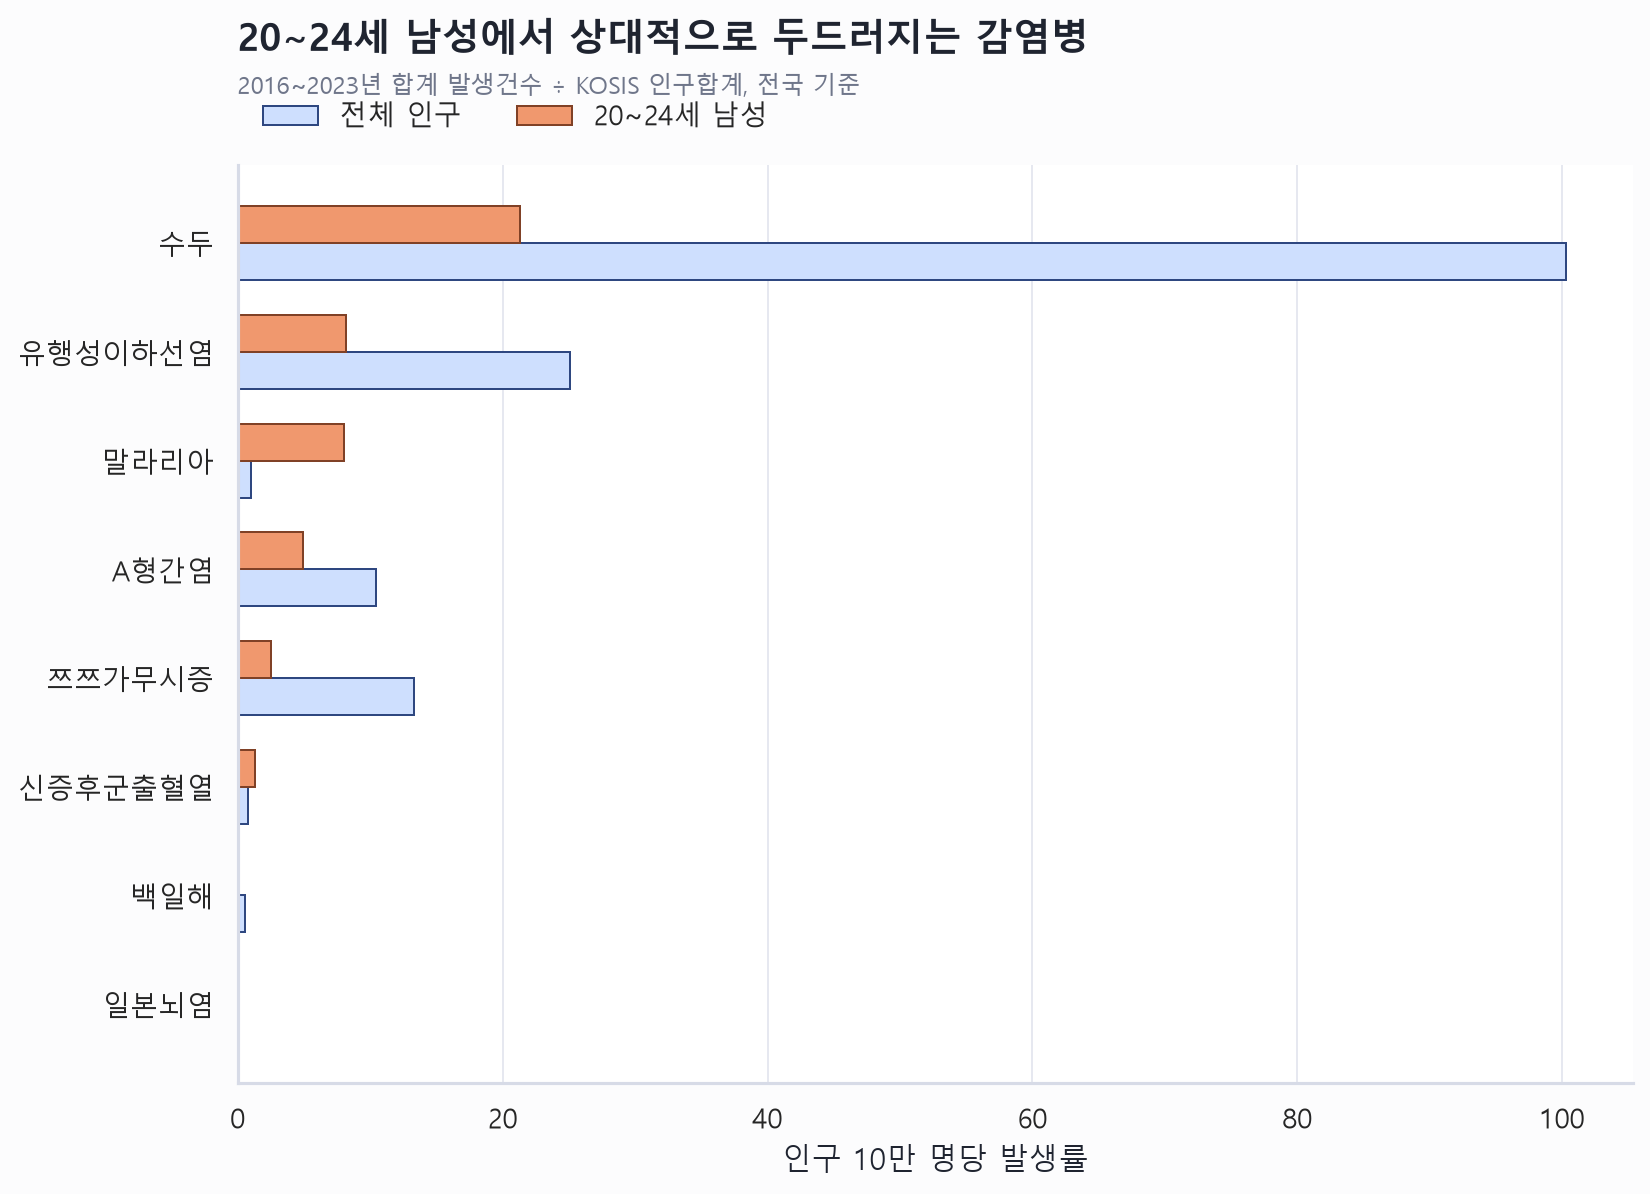

In [14]:
# 14. 20~24세 남성 발생률 vs 전체 인구 발생률
bar_data = metrics.sort_values("rate_male_20_24", ascending=True)
fig, ax = plt.subplots(figsize=(10, 6.8))
y = np.arange(len(bar_data))
height = 0.34
ax.barh(y - height/2, bar_data["rate_all"], height, color=BLUE["light"], edgecolor=BLUE["dark"], linewidth=0.8, label="전체 인구")
ax.barh(y + height/2, bar_data["rate_male_20_24"], height, color=ORANGE["base"], edgecolor=ORANGE["dark"], linewidth=0.8, label="20~24세 남성")
ax.set_yticks(y, bar_data["disease"])
ax.set_xlabel("인구 10만 명당 발생률")
ax.grid(axis="y", visible=False)
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.01), frameon=False, ncol=2)
add_header(fig, ax, "20~24세 남성에서 상대적으로 두드러지는 감염병", "2016~2023년 합계 발생건수 ÷ KOSIS 인구합계, 전국 기준")
bar_path = save_figure(fig, "01_청년남성_발생률_비교")
display(Image(filename=str(bar_path)))


### 5-b) 지역 RQ 히트맵

- 행: 17개 시도
- 열: 8개 질환
- 셀 숫자: 원래 RQ
- 색: `log2(RQ)`

로그를 쓰면 RQ 0.5와 2.0이 전국 평균 1을 기준으로 대칭적으로 보인다. 셀 숫자는 원 RQ를 남겨 해석 가능성을 유지한다.

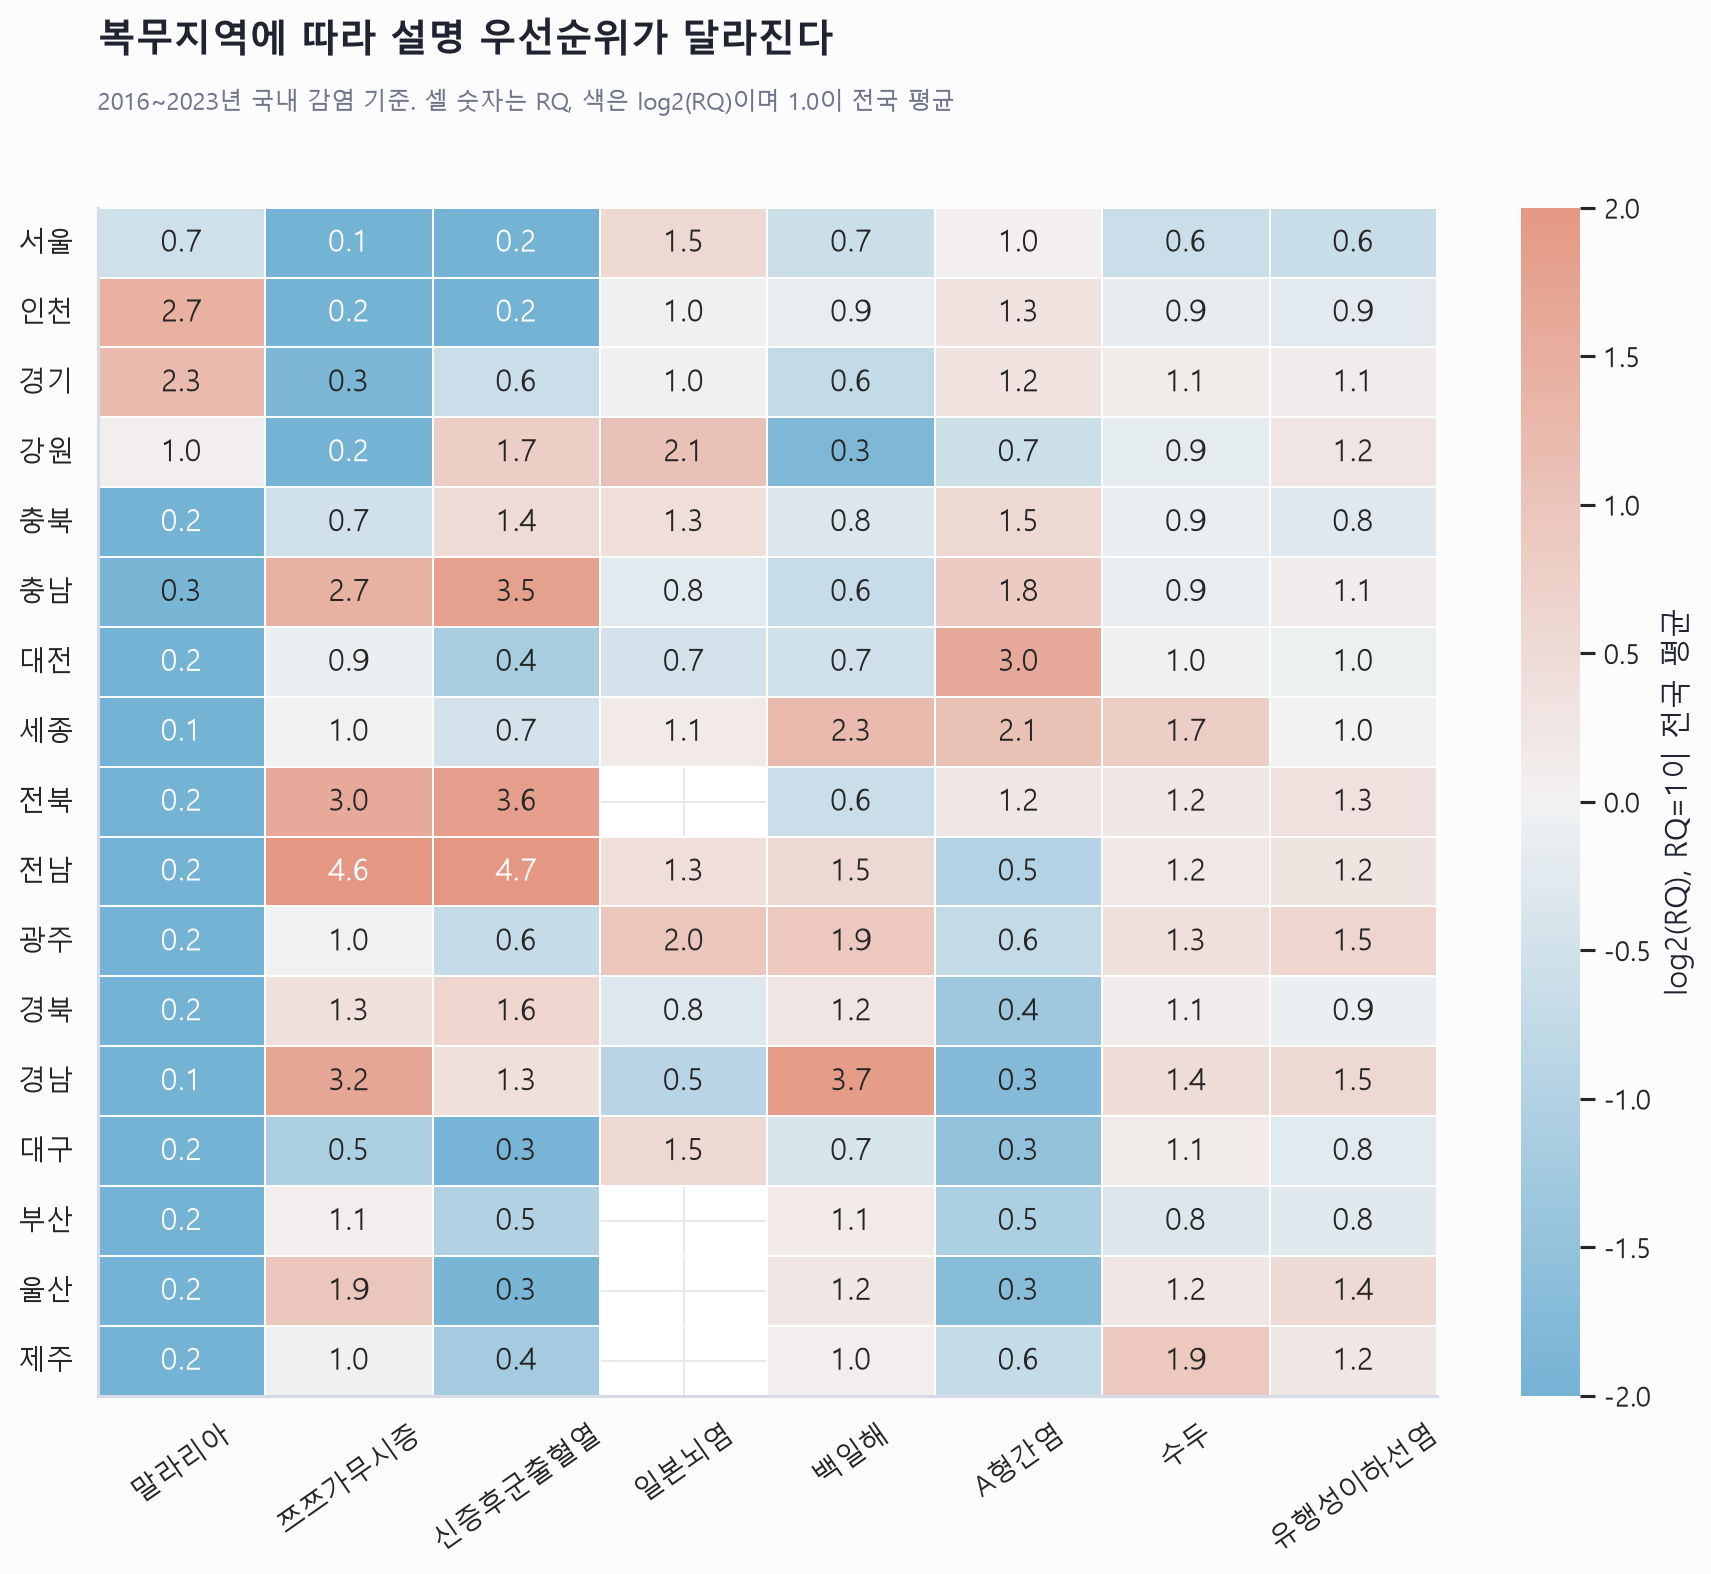

In [15]:
# 15. 지역 집중도 히트맵: 색은 log2(RQ), 표기는 원 RQ
region_order = ["서울", "인천", "경기", "강원", "충북", "충남", "대전", "세종", "전북", "전남", "광주", "경북", "경남", "대구", "부산", "울산", "제주"]
disease_order = metrics.sort_values("nps", ascending=False)["disease"].tolist()
rq_matrix = period_region.pivot(index="region", columns="disease", values="rq").reindex(index=region_order, columns=disease_order).astype(float)
log_rq = np.log2(rq_matrix.where(rq_matrix > 0)).clip(-2, 2)
annot = rq_matrix.map(lambda x: "" if pd.isna(x) else f"{x:.1f}")
cmap = sns.diverging_palette(230, 25, s=60, l=70, center="light", as_cmap=True)
fig, ax = plt.subplots(figsize=(12, 8.8))
sns.heatmap(log_rq, cmap=cmap, center=0, vmin=-2, vmax=2, annot=annot, fmt="", linewidths=0.7, linecolor="#FFFFFF", cbar_kws={"label": "log2(RQ), RQ=1이 전국 평균"}, ax=ax)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=35)
ax.tick_params(axis="y", rotation=0)
add_header(fig, ax, "복무지역에 따라 설명 우선순위가 달라진다", "2016~2023년 국내 감염 기준. 셀 숫자는 RQ, 색은 log2(RQ)이며 1.0이 전국 평균")
heatmap_path = save_figure(fig, "02_지역별_RQ_히트맵")
display(Image(filename=str(heatmap_path)))


### 5-c) 월별 계절성 소형 다중선

질환별 절대 건수가 너무 다르므로 건수가 아니라 연간 발생 중 월 비중을 시각화.

- 말라리아의 여름
- 쯔쯔가무시증·신증후군출혈열의 가을 집중이 분명해진다.

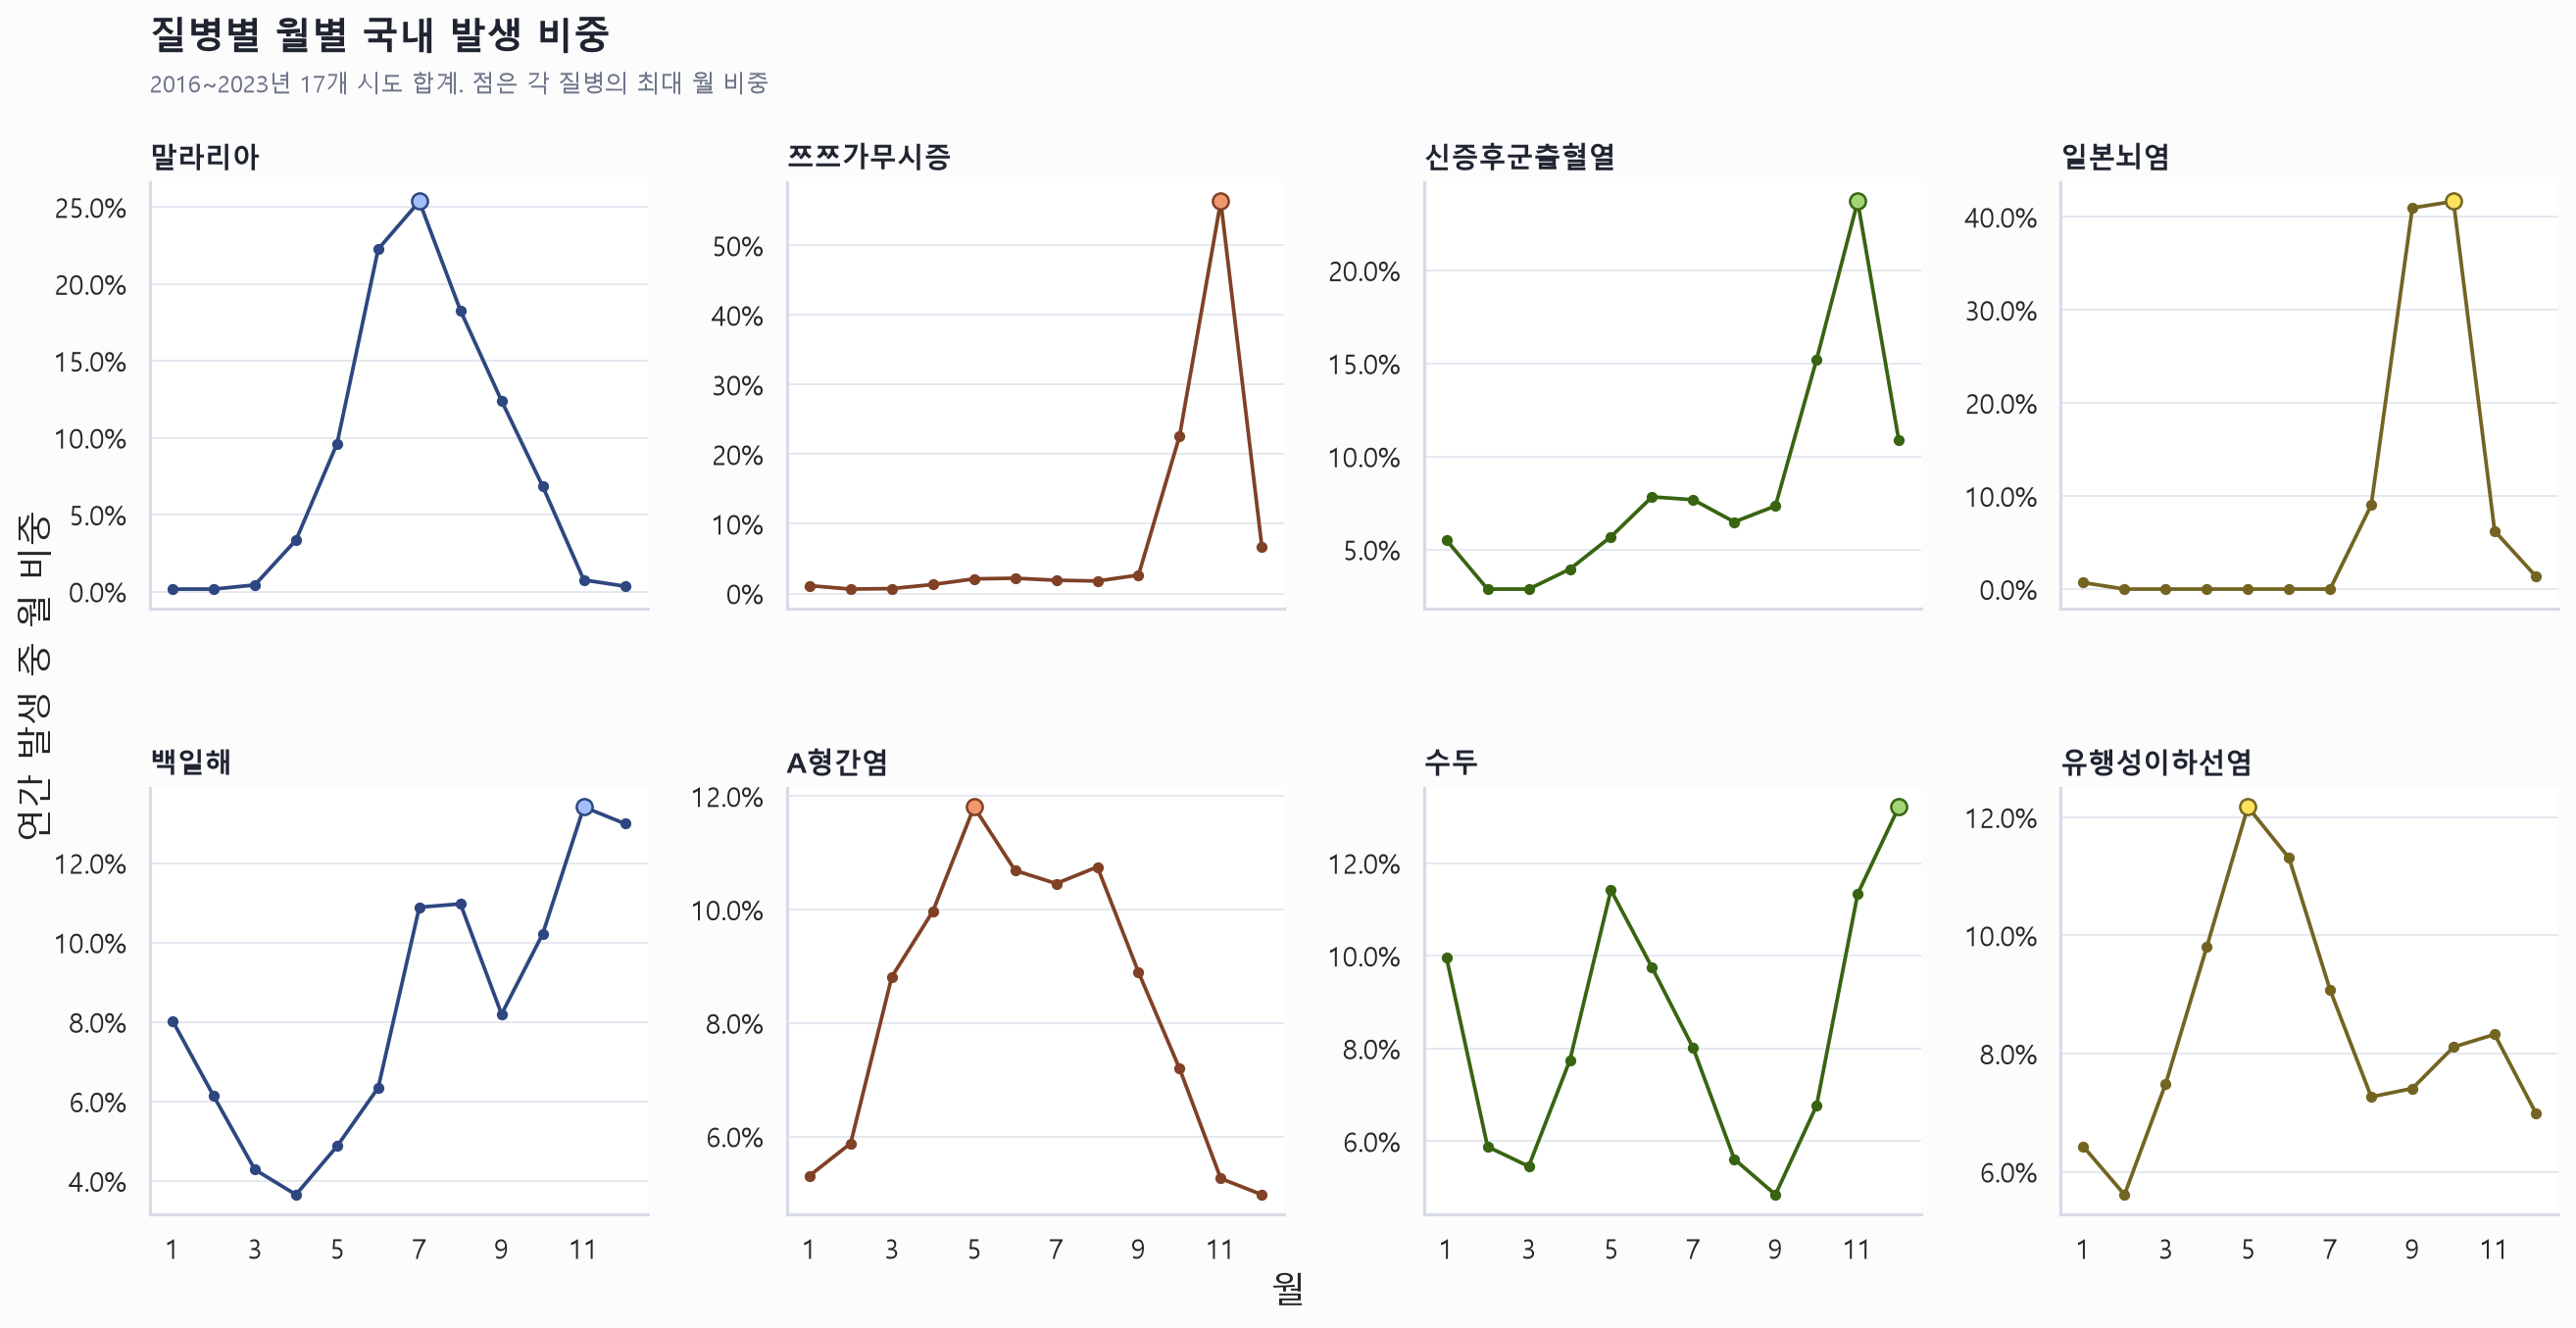

In [16]:
# 16. 월별 계절성 소형 다중선
fig, axes = plt.subplots(2, 4, figsize=(15, 7.8), sharex=True, sharey=False)
palette = [BLUE, ORANGE, OLIVE, GOLD, BLUE, ORANGE, OLIVE, GOLD]
for ax, disease, color in zip(axes.flat, disease_order, palette):
    part = monthly_pattern[monthly_pattern["disease"].eq(disease)].sort_values("month")
    ax.plot(part["month"], part["monthly_share"] * 100, color=color["dark"], marker="o", markersize=3.5, linewidth=1.5)
    peak = part.loc[part["monthly_share"].idxmax()]
    ax.scatter([peak["month"]], [peak["monthly_share"] * 100], s=42, color=color["base"], edgecolor=color["dark"], zorder=4)
    ax.set_title(disease, loc="left", fontsize=11, fontweight="bold", color=TOKENS["ink"])
    ax.set_xticks([1, 3, 5, 7, 9, 11])
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.grid(axis="x", visible=False)
    sns.despine(ax=ax)
fig.text(0.07, 0.98, "질병별 월별 국내 발생 비중", ha="left", va="top", fontsize=15, fontweight="bold", color=TOKENS["ink"])
fig.text(0.07, 0.94, "2016~2023년 17개 시도 합계. 점은 각 질병의 최대 월 비중", ha="left", va="top", fontsize=9.5, color=TOKENS["muted"])
fig.supxlabel("월", y=0.04)
fig.supylabel("연간 발생 중 월 비중", x=0.02)
fig.subplots_adjust(top=0.86, bottom=0.11, left=0.07, right=0.98, hspace=0.42, wspace=0.28)
season_path = save_figure(fig, "03_질병별_월별_계절성")
display(Image(filename=str(season_path)))


### 5-d) NPS 순위 차트

8개 질환을 NPS로 정렬한다.

축에 “숏리스트 내부 상대점수”와 “발병확률이 아님”을 표시해 오해를 방지한다.

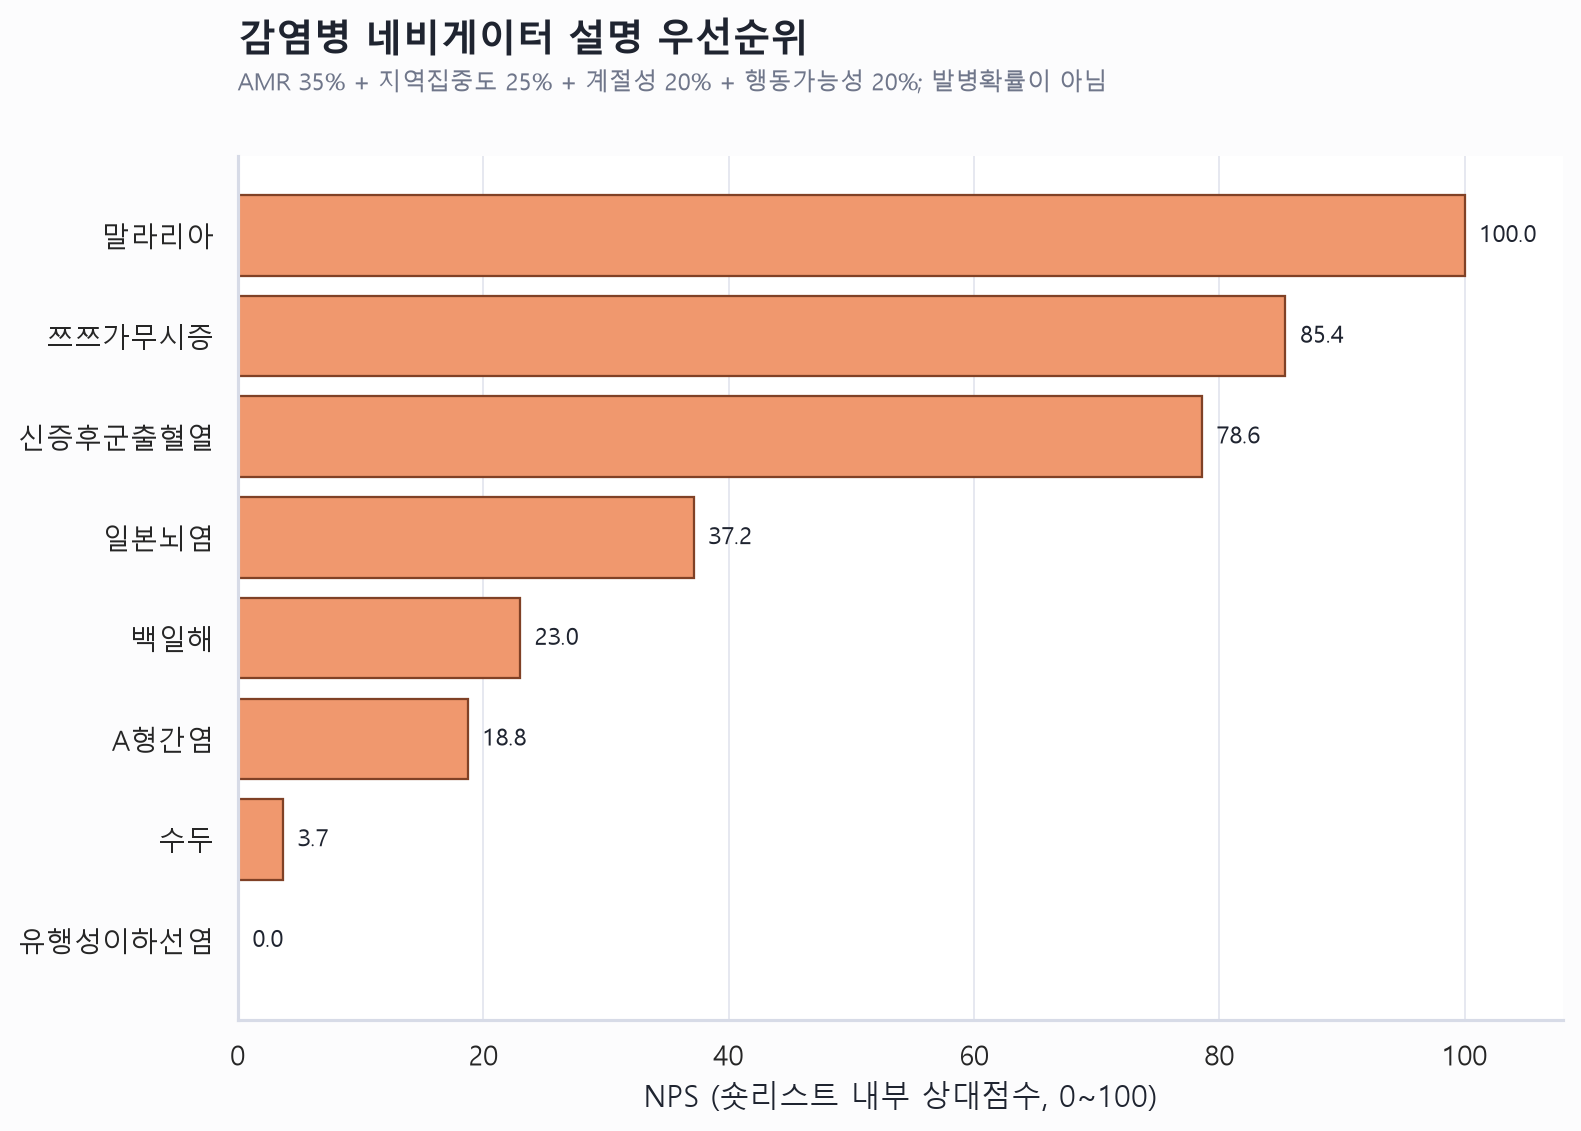

In [17]:
# 17. NPS 우선순위
nps_plot = metrics.sort_values("nps", ascending=True)
fig, ax = plt.subplots(figsize=(9.5, 6.4))
bars = ax.barh(nps_plot["disease"], nps_plot["nps"], color=ORANGE["base"], edgecolor=ORANGE["dark"], linewidth=0.9)
for bar, value in zip(bars, nps_plot["nps"]):
    ax.text(value + 1.2, bar.get_y() + bar.get_height()/2, f"{value:.1f}", va="center", fontsize=9, color=TOKENS["ink"])
ax.set_xlim(0, 108)
ax.set_xlabel("NPS (숏리스트 내부 상대점수, 0~100)")
ax.grid(axis="y", visible=False)
add_header(fig, ax, "감염병 네비게이터 설명 우선순위", "AMR 35% + 지역집중도 25% + 계절성 20% + 행동가능성 20%; 발병확률이 아님")
nps_path = save_figure(fig, "04_NPS_우선순위")
display(Image(filename=str(nps_path)))


### 5-e) 프로토타입 예시: 질병 카드

각 카드에 다음을 모은다.

- 기본 NPS·순위
- 20~24세 남성 발생률
- AMR·SMR
- 집중 지역·집중 시기
- 행동 태그
- 확률·보험판정이 아니라는 면책문구

이 카드는 Streamlit 화면에서 바로 재사용할 수 있다.

,disease,rank,card_path,action_text
0,말라리아,1,C:\Users\user\Documents\AI 활용 경진대회\outputs\감염병...,지역·시기 확인 · 노출 예방수칙 · 증상 시 조기 대응 · 군의료·비용 경로 확인
1,쯔쯔가무시증,2,C:\Users\user\Documents\AI 활용 경진대회\outputs\감염병...,지역·시기 확인 · 노출 예방수칙 · 증상 시 조기 대응 · 군의료·비용 경로 확인
2,신증후군출혈열,3,C:\Users\user\Documents\AI 활용 경진대회\outputs\감염병...,예방접종 확인 · 지역·시기 확인 · 노출 예방수칙 · 증상 시 조기 대응 · 군의...
3,일본뇌염,4,C:\Users\user\Documents\AI 활용 경진대회\outputs\감염병...,예방접종 확인 · 지역·시기 확인 · 노출 예방수칙 · 증상 시 조기 대응 · 군의...
4,백일해,5,C:\Users\user\Documents\AI 활용 경진대회\outputs\감염병...,예방접종 확인 · 노출 예방수칙 · 증상 시 조기 대응 · 군의료·비용 경로 확인
5,A형간염,6,C:\Users\user\Documents\AI 활용 경진대회\outputs\감염병...,예방접종 확인 · 노출 예방수칙 · 증상 시 조기 대응 · 군의료·비용 경로 확인
6,수두,7,C:\Users\user\Documents\AI 활용 경진대회\outputs\감염병...,예방접종 확인 · 노출 예방수칙 · 증상 시 조기 대응 · 군의료·비용 경로 확인
7,유행성이하선염,8,C:\Users\user\Documents\AI 활용 경진대회\outputs\감염병...,예방접종 확인 · 노출 예방수칙 · 증상 시 조기 대응 · 군의료·비용 경로 확인


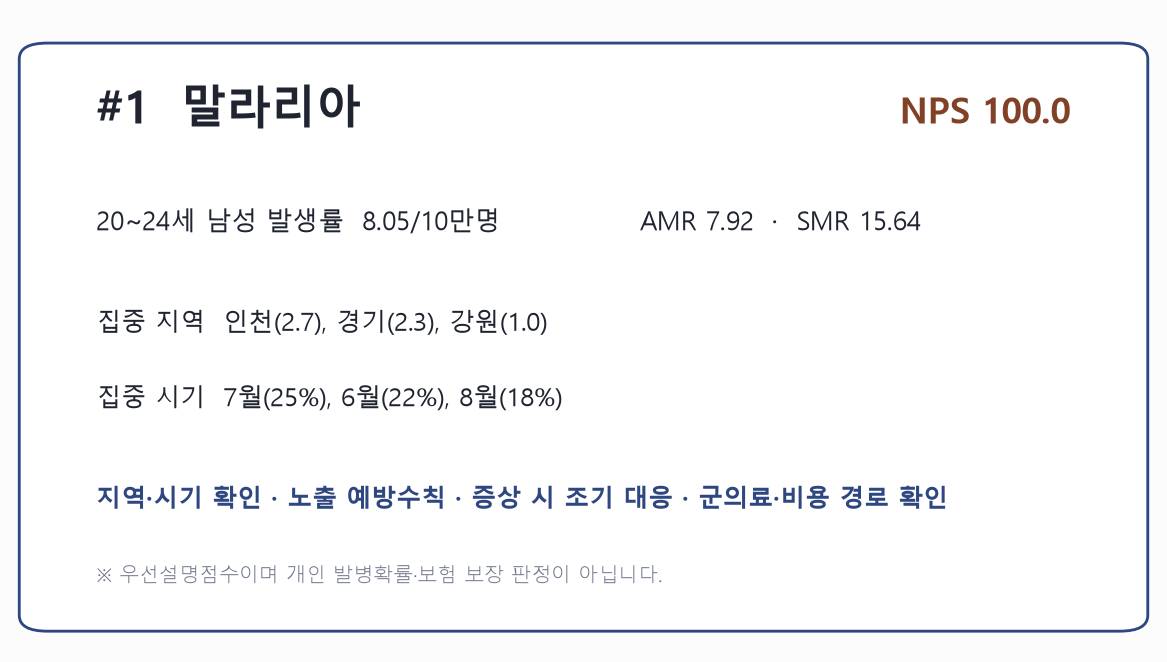

In [18]:
# 18. 질병 카드 8장 생성
def action_text(row):
    actions = []
    if row.get("vaccination", 0): actions.append("예방접종 확인")
    if row.get("region_season", 0): actions.append("지역·시기 확인")
    if row.get("exposure_prevention", 0): actions.append("노출 예방수칙")
    if row.get("early_response", 0): actions.append("증상 시 조기 대응")
    if row.get("navigation", 0): actions.append("군의료·비용 경로 확인")
    return " · ".join(actions)


card_rows = []
for _, row in metrics.iterrows():
    disease = row["disease"]
    fig, ax = plt.subplots(figsize=(8.6, 4.8))
    ax.set_axis_off()
    card = FancyBboxPatch((0.02, 0.04), 0.96, 0.90, boxstyle="round,pad=0.018,rounding_size=0.025", transform=ax.transAxes, facecolor="#FFFFFF", edgecolor=BLUE["dark"], linewidth=1.2)
    ax.add_patch(card)
    ax.text(0.07, 0.83, f"#{int(row['rank'])}  {disease}", transform=ax.transAxes, fontsize=19, fontweight="bold", color=TOKENS["ink"])
    ax.text(0.93, 0.83, f"NPS {row['nps']:.1f}", transform=ax.transAxes, fontsize=15, fontweight="bold", ha="right", color=ORANGE["dark"])
    ax.text(0.07, 0.66, f"20~24세 남성 발생률  {row['rate_male_20_24']:.2f}/10만명", transform=ax.transAxes, fontsize=11, color=TOKENS["ink"])
    ax.text(0.55, 0.66, f"AMR {row['amr']:.2f}  ·  SMR {row['smr']:.2f}", transform=ax.transAxes, fontsize=11, color=TOKENS["ink"])
    ax.text(0.07, 0.50, f"집중 지역  {row['top_regions']}", transform=ax.transAxes, fontsize=10.5, color=TOKENS["ink"])
    ax.text(0.07, 0.38, f"집중 시기  {row['top_months']}", transform=ax.transAxes, fontsize=10.5, color=TOKENS["ink"])
    ax.text(0.07, 0.22, action_text(row), transform=ax.transAxes, fontsize=10.5, color=BLUE["dark"], fontweight="bold")
    ax.text(0.07, 0.10, "※ 우선설명점수이며 개인 발병확률·보험 보장 판정이 아닙니다.", transform=ax.transAxes, fontsize=8.5, color=TOKENS["muted"])
    card_path = CARD_DIR / f"{int(row['rank']):02d}_{disease}.png"
    fig.savefig(card_path, dpi=170, bbox_inches="tight", facecolor=TOKENS["surface"])
    plt.close(fig)
    card_rows.append({"disease": disease, "rank": int(row["rank"]), "card_path": str(card_path), "action_text": action_text(row)})

disease_cards = pd.DataFrame(card_rows).sort_values("rank")
display(disease_cards)
display(Image(filename=disease_cards.iloc[0]["card_path"]))


## 산출물 저장

원본 long 테이블, 숏리스트 테이블, RQ, 계절성, NPS, PNPS, RAG 메타데이터, 카드 인덱스를 UTF-8 CSV로 저장한다. `analysis_manifest.json`에는 사용 기간·가중치·산출물 목록·검증상태가 기록된다.

In [19]:
# 19. 분석 산출물 저장
sex_age_long.to_csv(PROCESSED_DIR / "sex_age_long_all_2016_2025.csv", index=False, encoding="utf-8-sig")
sex_age_shortlist.to_csv(PROCESSED_DIR / "sex_age_long_shortlist_2016_2025.csv", index=False, encoding="utf-8-sig")
regional_long.to_csv(PROCESSED_DIR / "regional_long_all_2016_2025.csv", index=False, encoding="utf-8-sig")
regional_shortlist.to_csv(PROCESSED_DIR / "regional_long_shortlist_2016_2025.csv", index=False, encoding="utf-8-sig")
population_long.to_csv(PROCESSED_DIR / "population_long_2016_2023.csv", index=False, encoding="utf-8-sig")
period_region.to_csv(PROCESSED_DIR / "region_rq_2016_2023.csv", index=False, encoding="utf-8-sig")
monthly_pattern.to_csv(PROCESSED_DIR / "monthly_seasonality_2016_2023.csv", index=False, encoding="utf-8-sig")
region_month_features.to_csv(PROCESSED_DIR / "region_month_features_2016_2023.csv", index=False, encoding="utf-8-sig")
region_seasonality.to_csv(PROCESSED_DIR / "region_seasonality_2016_2023.csv", index=False, encoding="utf-8-sig")
nps_table.to_csv(PROCESSED_DIR / "nps_shortlist_2016_2023.csv", index=False, encoding="utf-8-sig")
pnps_examples.to_csv(PROCESSED_DIR / "pnps_examples.csv", index=False, encoding="utf-8-sig")
rag_metadata_seed.to_csv(PROCESSED_DIR / "rag_metadata_seed.csv", index=False, encoding="utf-8-sig")
quality_summary.to_csv(PROCESSED_DIR / "data_quality_summary.csv", index=False, encoding="utf-8-sig")
shortlist_coverage.to_csv(PROCESSED_DIR / "shortlist_coverage.csv", index=False, encoding="utf-8-sig")
disease_cards.to_csv(PROCESSED_DIR / "disease_cards_index.csv", index=False, encoding="utf-8-sig")

manifest = {
    "analysis_period": MAIN_YEARS,
    "latest_data_period": ALL_YEARS,
    "shortlist": SHORTLIST,
    "nps_weights": NPS_WEIGHTS,
    "input_directory": str(DATA_DIR),
    "outputs": sorted(str(p.relative_to(OUTPUT_DIR)) for p in OUTPUT_DIR.rglob("*") if p.is_file()),
    "validation_status": "PASS" if not (quality_summary["status"] == "FAIL").any() and not (validation_checks["status"] == "FAIL").any() else "FAIL",
}
(OUTPUT_DIR / "analysis_manifest.json").write_text(json.dumps(manifest, ensure_ascii=False, indent=2), encoding="utf-8")

print(f"저장 완료: {OUTPUT_DIR}")
print(f"검증 상태: {manifest['validation_status']}")


저장 완료: C:\Users\user\Documents\AI 활용 경진대회\outputs\감염병_분석_Actionability_문서근거
검증 상태: PASS


## Takeaways

- 이 분석의 수상 포인트는 예측모델의 복잡성이 아니라, 주최기관 공개데이터를 실제 서비스 의사결정 구조로 변환했다는 점이다.
- 결과 해석은 NPS 순위, AMR·SMR, 지역 RQ, 월별 계절성을 함께 보아야 한다.
- 지역 파일의 `국외` 감염은 보존하되 복무지역 위험 점수에서는 제외했다.
- 2024~2025년은 인구 분모가 없어 발생률 기반 NPS에서 제외했다. 최신 KOSIS 분모를 추가 확보하면 같은 코드로 확장할 수 있다.
- 병무청 BMI 자료는 감염병 예측에 사용하지 않고 페르소나·코호트 설명용으로만 남겼다.
- Actionability 태그는 공식 예방접종·예방수칙·군의료·비용 안내 문서와 연결해 최종 제출 전에 근거 URL을 확정해야 한다.
- `calculate_pnps(region, month)`는 계획서 식 `NPS × RQ × 지역별 월비중`을 구현하며, 결과는 선택 조건 안의 상대 순위로만 해석한다.
- `rag_metadata_seed.csv`는 내일 RAG에서 질병·문서유형 필터로 사용할 정량 메타데이터다. 이는 LLM 재학습 데이터가 아니라 검색 문맥이다.
